# Utilize-Indecision vs Bradley-Terry — Eight-Method Comparison

Runs eight methods on a 5×5 (τ_r, τ_κ) grid and produces L1 and cosine-similarity plots. The Utilize-Indecision algorithm is the multi-tier likelihood method that explicitly models indecisive responses (`indifferent` and `incomparable`); Bradley-Terry is the binary-response baseline.

All methods share the oracle weights, holdout set, candidate query pool, and oracle response noise per trial — only their internal MCMC / forced-choice rng differs.

**Methods**

1. `multiframe` — **Utilize-Indecision (4-outcome, noise known)**: full 4-outcome likelihood with logistic noise. *Ceiling.*
2. `multiframe_3outcome` — **Utilize-Indecision (3-outcome)**: collapses indifferent + incomparable into one `indecisive` label.
3. `multiframe_unknown_family` — **Utilize-Indecision (no noise-family knowledge)**: fits a 3-component Gaussian mixture for the noise jointly with ω.
4. `bt_laplace_bald` — **BT (Skip)**: drops indecisive responses.
5. `bt_laplace_bald_k` — **BT (K-Decisive)**: runs until k decisive responses (cheats on query budget).
6. `bt_laplace_bald_random` — **BT (Random FC)**: random forced choice on indecisive responses.
7. `bt_laplace_bald_lex` — **BT (Lex FC)**: lexicographic forced choice over a feature ranking.
8. `bt_mog` — **BT (MoG noise)**: BT-style 2-outcome learner with MoG noise (the BT analogue of `multiframe_unknown_family`).

**Workflow.** Run cells 1–11 to define helpers, the smoke cell to verify dispatch, the sweep cell to run the full 5×5 (or use `run_big_sweep.py` on the cluster), then the plot cell.


In [4]:
# ============================================================================
# CELL 1: Imports, Constants, and Helper Utilities
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Set, Optional, Callable, Dict
from scipy.optimize import minimize
from scipy.special import expit as sigmoid, gammaln
from scipy.stats import logistic as logistic_dist, gennorm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# Constants
# ============================================================================
FEATURE_NAMES = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
DIM = len(FEATURE_NAMES)

# Default model parameters
TAU = 0.25           # Indifference threshold
TAU_PRIME = 0.25     # Incomparability threshold
LAMBDA_X = 1.0       # Feature scaling

# Supported noise distributions for the latent margin Delta:
#   'logistic' : symmetric, heavy tails (default original setting).
#   'normal'   : Gaussian.
#   'gumbel'   : asymmetric extreme-value (mode 0, right-skewed).
#   'gennorm'  : generalized normal / exponential-power family with shape beta.
#                beta=1 -> Laplace, beta=2 -> Gaussian, beta->inf -> uniform.
NOISE_TYPES = ('logistic', 'normal', 'gumbel', 'gennorm')

# ============================================================================
# Data Structures
# ============================================================================
@dataclass
class Patient:
    """Represents a patient with feature values."""
    elderlyDep: int
    lifeYearsGained: float
    obesity: int
    weeklyWorkhours: int
    yearsWaiting: int

    def to_array(self) -> np.ndarray:
        return np.array([
            self.elderlyDep, self.lifeYearsGained, self.obesity,
            self.weeklyWorkhours, self.yearsWaiting
        ], dtype=float)

@dataclass
class PairwiseQuery:
    """Represents a pairwise comparison query."""
    patient_left: Patient
    patient_right: Patient
    context: Optional[str] = None

# ============================================================================
# Helper Functions
# ============================================================================
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Compute cosine similarity between two vectors."""
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a < 1e-10 or norm_b < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))

def l1_error(omega_hat: np.ndarray, oracle_weights: np.ndarray) -> float:
    """Compute L1 error between estimated and true weights."""
    return float(np.sum(np.abs(omega_hat - oracle_weights)))

def entropy(probs: np.ndarray) -> float:
    """Compute entropy H[p] = -sum(p * log(p))."""
    probs = np.clip(probs, 1e-15, 1.0)
    return -np.sum(probs * np.log(probs))

def phi(query: PairwiseQuery) -> np.ndarray:
    """Feature difference vector: x_left - x_right."""
    return query.patient_left.to_array() - query.patient_right.to_array()

def generate_random_patient_normalized(rng: Optional[np.random.Generator] = None) -> Patient:
    """Generate a random patient with features in [0, 1]."""
    if rng is None:
        rng = np.random.default_rng()
    return Patient(
        elderlyDep=rng.uniform(0, 1),
        lifeYearsGained=rng.uniform(0, 1),
        obesity=rng.uniform(0, 1),
        weeklyWorkhours=rng.uniform(0, 1),
        yearsWaiting=rng.uniform(0, 1),
    )

def generate_candidate_queries(
    n_candidates: int = 100,
    rng: Optional[np.random.Generator] = None,
) -> List[PairwiseQuery]:
    """Generate candidate queries with normalized features."""
    if rng is None:
        rng = np.random.default_rng()
    candidates = []
    for _ in range(n_candidates):
        left = generate_random_patient_normalized(rng)
        right = generate_random_patient_normalized(rng)
        candidates.append(PairwiseQuery(left, right))
    return candidates


def lex_choice(
    query: PairwiseQuery,
    ranking: Optional[List[int]] = None,
    rng: Optional[np.random.Generator] = None,
) -> str:
    """
    Lexicographic forced-choice rule.

    Walks features in priority order (`ranking`) and picks the option whose
    feature value is larger at the first feature where the two options differ.
    If all ranked features tie, falls back to a coin flip (or 'left' if no rng).

    Args:
        query: PairwiseQuery to decide on.
        ranking: Feature indices in priority order. Defaults to [0, 1, ..., DIM-1].
        rng: Optional rng for tie-breaking.

    Returns:
        'left' or 'right'.
    """
    if ranking is None:
        ranking = list(range(DIM))
    x_left = query.patient_left.to_array()
    x_right = query.patient_right.to_array()
    for j in ranking:
        if x_left[j] > x_right[j]:
            return 'left'
        if x_left[j] < x_right[j]:
            return 'right'
    # All ranked features tie -- random fallback.
    if rng is not None:
        return 'left' if rng.random() < 0.5 else 'right'
    return 'left'


print(f"Initialized with {DIM} features: {FEATURE_NAMES}")
print(f"Default thresholds: tau_r={TAU}, tau_kappa={TAU_PRIME}")
print(f"Supported noise types: {NOISE_TYPES}")


Initialized with 5 features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
Default thresholds: tau_r=0.25, tau_kappa=0.25
Supported noise types: ('logistic', 'normal', 'gumbel', 'gennorm')


In [ ]:
# ============================================================================
# CELL 2: Multi-Frame Model (DGP + Likelihood + Inference)
# ============================================================================
# These functions define the "true" multi-frame model used as the DGP
# and for Bayesian inference. Generalized to handle multiple noise families:
# logistic, normal, gumbel, and gennorm (exponential power with shape beta).
# ============================================================================

def _sample_noise(
    rng: np.random.Generator,
    noise_type: str,
    scale_delta: float,
    shape_beta: float = 2.0,
) -> float:
    """Draw one scalar noise realization (legacy; kept for callers that still want one at a time)."""
    return float(_sample_noise_batch(rng, noise_type, scale_delta, shape_beta, 1)[0])


def _sample_noise_batch(
    rng: np.random.Generator,
    noise_type: str,
    scale_delta: float,
    shape_beta: float,
    n: int,
) -> np.ndarray:
    """Vectorized noise draws. ~10-100x faster than calling _sample_noise in a loop."""
    if noise_type == 'logistic':
        return rng.logistic(0.0, scale_delta, size=n)
    if noise_type == 'normal':
        return rng.normal(0.0, scale_delta, size=n)
    if noise_type == 'gumbel':
        return rng.gumbel(0.0, scale_delta, size=n)
    if noise_type == 'gennorm':
        return gennorm.rvs(beta=shape_beta, loc=0.0, scale=scale_delta,
                           size=n, random_state=rng)
    raise ValueError(f"Unknown noise_type {noise_type!r}; supported: {NOISE_TYPES}")


def _noise_cdf(x, noise_type: str, scale_delta: float, shape_beta: float = 2.0):
    """Closed-form CDF of the latent-margin noise distribution (centered at 0).

    Used by compute_response_probs_mc to get exact response probabilities
    without Monte Carlo sampling.
    """
    if noise_type == 'logistic':
        return sigmoid(x / scale_delta)
    if noise_type == 'normal':
        from scipy.stats import norm
        return norm.cdf(x, loc=0.0, scale=scale_delta)
    if noise_type == 'gumbel':
        # Standard Gumbel-max CDF (matches np.random.gumbel).
        return np.exp(-np.exp(-x / scale_delta))
    if noise_type == 'gennorm':
        return gennorm.cdf(x, beta=shape_beta, loc=0.0, scale=scale_delta)
    raise ValueError(f"Unknown noise_type {noise_type!r}; supported: {NOISE_TYPES}")


def compute_frame_gaps(
    query: PairwiseQuery,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    tau: float = TAU
) -> Tuple[np.ndarray, Set[int]]:
    """
    Compute frame-level gaps and identify active frames.
    Returns: (gaps array, set of active frame indices)
    """
    feature_diff = phi(query)
    if V is not None:
        gaps = lambda_x * (V @ feature_diff)
    else:
        gaps = lambda_x * feature_diff
    active_frames = set(np.where(np.abs(gaps) > 0)[0].tolist())
    return gaps, active_frames


def compute_aggregate_scores(
    gaps: np.ndarray,
    weights: np.ndarray,
    active_frames: Set[int]
) -> Tuple[float, float]:
    """
    Compute aggregate preference score Delta(omega) and intensity r(omega).
    """
    delta_omega = float(np.dot(gaps, weights))
    r_omega = float(sum(weights[j] * abs(gaps[j]) for j in active_frames))
    return delta_omega, r_omega


def create_noise_fn(
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> Callable:
    """
    Create noise function for latent margins.
    - Delta gets additive noise drawn from `noise_type`.
    - r is currently passed through unchanged (multiplicative noise hook reserved).

    The returned closure captures the rng for reproducibility.
    `shape_beta` is only used when noise_type='gennorm'.
    """
    if rng is None:
        rng = np.random.default_rng()
    if noise_type not in NOISE_TYPES:
        raise ValueError(f"Unknown noise_type {noise_type!r}; supported: {NOISE_TYPES}")

    def noise_fn(delta: float, r: float) -> Tuple[float, float]:
        eps_delta = _sample_noise(rng, noise_type, scale_delta, shape_beta)
        return delta + eps_delta, r
    return noise_fn


def predict_response_noisy(
    query: PairwiseQuery,
    weights: np.ndarray,
    noise_fn: Callable,
    tau: float = TAU,
    lambda_x: float = LAMBDA_X,
    tau_prime: float = TAU_PRIME,
    V: np.ndarray = None,
) -> str:
    """
    Generate response from multi-frame model with noise.
    Returns: 'left', 'right', 'indifferent', or 'incomparable'

    Note: noise_fn should be created with create_noise_fn(rng=...) to ensure
    reproducibility. The noise_fn closure captures its rng internally.
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, weights, active_frames)
    delta_tilde, r = noise_fn(delta, r)

    if r < tau:
        return 'indifferent'
    if abs(delta_tilde) < tau_prime * r:
        return 'incomparable'
    return 'left' if delta_tilde >= tau_prime * r else 'right'


def compute_response_probs_mc(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 200,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> np.ndarray:
    """
    Compute P(y | q, omega) for all 4 response types using the CLOSED-FORM
    noise CDF — no Monte Carlo. Supports arbitrary noise families via
    `noise_type` (and `shape_beta` when noise_type='gennorm').

    The `n_mc_samples` and `rng` parameters are kept for API compatibility
    with the previous MC implementation but are unused.

    Returns: [p_left, p_right, p_indifferent, p_incomparable].
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, omega, active_frames)

    # Fast-path: r < tau means the oracle always returns indifferent.
    if r < tau:
        return np.array([0.0, 0.0, 1.0, 0.0])

    threshold = tau_prime * r
    F_hi = _noise_cdf(threshold - delta, noise_type, scale_delta, shape_beta)
    F_lo = _noise_cdf(-threshold - delta, noise_type, scale_delta, shape_beta)
    p_left = 1.0 - F_hi
    p_right = F_lo
    p_incomp = max(0.0, F_hi - F_lo)  # numerical guard
    return np.array([p_left, p_right, 0.0, p_incomp])


def compute_transcript_log_likelihood(
    transcript: List[Tuple[PairwiseQuery, str]],
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 100,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> float:
    """Compute total log-likelihood of transcript under multi-frame model."""
    if rng is None:
        rng = np.random.default_rng()

    response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    ll = 0.0
    for query, response in transcript:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng,
            shape_beta=shape_beta,
        )
        prob = probs[response_idx[response]]
        ll += np.log(max(prob, 1e-10))
    return ll


def compute_response_probs_3outcome(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 200,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> np.ndarray:
    """3-outcome variant: P(y | q, omega) where y is one of
    {'left', 'right', 'indecisive'}. 'indecisive' collapses 'indifferent' and
    'incomparable' from the underlying 4-outcome model.

    Returns: [p_left, p_right, p_indecisive].
    """
    p4 = compute_response_probs_mc(
        query, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples, rng,
        shape_beta=shape_beta,
    )
    return np.array([p4[0], p4[1], p4[2] + p4[3]])


def compute_transcript_log_likelihood_3outcome(
    transcript: List[Tuple[PairwiseQuery, str]],
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 100,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> float:
    """Total log-likelihood of a 3-outcome transcript (responses in
    {'left', 'right', 'indecisive'})."""
    response_idx = {'left': 0, 'right': 1, 'indecisive': 2}
    ll = 0.0
    for query, response in transcript:
        probs = compute_response_probs_3outcome(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng,
            shape_beta=shape_beta,
        )
        prob = probs[response_idx[response]]
        ll += np.log(max(prob, 1e-10))
    return ll


print("Multi-frame model functions defined (closed-form noise CDF, no MC):")
print("  - _sample_noise / _sample_noise_batch: dispatch over {logistic, normal, gumbel, gennorm}")
print("  - predict_response_noisy: DGP for generating responses")
print("  - compute_response_probs_mc: CLOSED-FORM P(y|q,omega) via _noise_cdf")
print("  - compute_transcript_log_likelihood: for MCMC, accepts shape_beta")


In [6]:
# ============================================================================
# CELL: Holdout Set Generation and Log-Loss Evaluators
# ============================================================================
# These functions create holdout sets for evaluation and compute log-loss metrics
# for both BT and multi-frame models.
# ============================================================================

def make_holdout_set(
    n_holdout: int,
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    rng_holdout: np.random.Generator,
    V: np.ndarray = None,
) -> List[Tuple[PairwiseQuery, str]]:
    """
    Generate a fixed holdout set for evaluation.

    The holdout set is labeled by the oracle DGP (predict_response_noisy). The
    noise distribution is whatever was baked into `noise_fn` (created via
    create_noise_fn with the desired noise_type/shape_beta).
    """
    holdout = []
    for _ in range(n_holdout):
        left = generate_random_patient_normalized(rng_holdout)
        right = generate_random_patient_normalized(rng_holdout)
        query = PairwiseQuery(left, right)
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        holdout.append((query, response))
    return holdout


def bt_log_loss(
    omega_hat: np.ndarray,
    holdout: List[Tuple[PairwiseQuery, str]],
    scale: float = 1.0,
    V: np.ndarray = None,
) -> float:
    """
    Compute BT log-loss on holdout set (decisive items only).
    """
    log_losses = []
    for query, response in holdout:
        if response not in ('left', 'right'):
            continue
        phi_vec = phi(query)
        if V is not None:
            phi_vec = V @ phi_vec
        logit = scale * np.dot(omega_hat, phi_vec)
        p_left = sigmoid(logit)
        p_left = np.clip(p_left, 1e-15, 1 - 1e-15)
        if response == 'left':
            log_losses.append(-np.log(p_left))
        else:
            log_losses.append(-np.log(1 - p_left))
    if len(log_losses) == 0:
        return float('nan')
    return float(np.mean(log_losses))


def multiframe_log_loss(
    omega_hat: np.ndarray,
    holdout: List[Tuple[PairwiseQuery, str]],
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 200,
    rng_mc: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> float:
    """
    Compute multi-frame log-loss on holdout set (all 4 response types).
    Accepts shape_beta for the gennorm noise family.
    """
    if rng_mc is None:
        rng_mc = np.random.default_rng()

    response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    log_losses = []
    for query, response in holdout:
        probs = compute_response_probs_mc(
            query, omega_hat, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng_mc,
            shape_beta=shape_beta,
        )
        p_y = probs[response_idx[response]]
        p_y = max(p_y, 1e-15)
        log_losses.append(-np.log(p_y))
    if len(log_losses) == 0:
        return float('nan')
    return float(np.mean(log_losses))


print("Holdout and log-loss functions defined (with shape_beta passthrough):")
print("  - make_holdout_set, bt_log_loss, multiframe_log_loss")


Holdout and log-loss functions defined (with shape_beta passthrough):
  - make_holdout_set, bt_log_loss, multiframe_log_loss


In [ ]:
# ============================================================================
# CELL 3: Multi-Frame MCMC Sampler
# ============================================================================
# Phase-1 sampler: hit-and-run on the simplex with a fixed (known) noise family
#                  (and known shape_beta when noise_type='gennorm').
# Phase-2 sampler: jointly samples (omega, beta) when the learner only knows
#                  the noise *kernel family* (gennorm) but not its shape.
# ============================================================================

def hit_and_run_simplex_step(
    x: np.ndarray,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """One hit-and-run step on the simplex {w : sum(w)=1, w>=0}."""
    if rng is None:
        rng = np.random.default_rng()

    dim = len(x)
    d = rng.standard_normal(dim)
    d = d - d.mean()
    norm = np.linalg.norm(d)
    if norm < 1e-12:
        return x.copy()
    d = d / norm

    t_min, t_max = -np.inf, np.inf
    for j in range(dim):
        if d[j] > 1e-12:
            t_min = max(t_min, -x[j] / d[j])
        elif d[j] < -1e-12:
            t_max = min(t_max, -x[j] / d[j])

    if t_min >= t_max - 1e-12:
        return x.copy()

    t = rng.uniform(t_min, t_max)
    new_x = x + t * d
    new_x = np.maximum(new_x, 0.0)
    new_x = new_x / new_x.sum()
    return new_x


def sample_posterior_hit_and_run(
    transcript: List[Tuple[PairwiseQuery, str]],
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_samples: int = 500,
    burn_in: int = 200,
    n_mc_samples: int = 50,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> Tuple[np.ndarray, float]:
    """
    Sample from posterior P(omega | transcript) using hit-and-run + MH.
    Phase-1: noise distribution (and shape_beta) are KNOWN to the learner.
    """
    if rng is None:
        rng = np.random.default_rng()

    dim = DIM
    omega = np.ones(dim) / dim

    ll_current = compute_transcript_log_likelihood(
        transcript, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples, rng,
        shape_beta=shape_beta,
    )

    samples = []
    n_accepted = 0

    for step in range(burn_in + n_samples):
        proposal = hit_and_run_simplex_step(omega, rng)
        ll_proposal = compute_transcript_log_likelihood(
            transcript, proposal, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng,
            shape_beta=shape_beta,
        )

        if np.log(rng.random()) < ll_proposal - ll_current:
            omega = proposal
            ll_current = ll_proposal
            if step >= burn_in:
                n_accepted += 1

        if step >= burn_in:
            samples.append(omega.copy())

    return np.array(samples), n_accepted / max(1, n_samples)


def sample_posterior_hit_and_run_3outcome(
    transcript: List[Tuple[PairwiseQuery, str]],
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_samples: int = 500,
    burn_in: int = 200,
    n_mc_samples: int = 50,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> Tuple[np.ndarray, float]:
    """
    Sample from posterior P(omega | transcript) for the 3-outcome learner.
    Hit-and-run on the simplex; identical structure to the 4-outcome sampler,
    but uses `compute_transcript_log_likelihood_3outcome` for the likelihood.
    """
    if rng is None:
        rng = np.random.default_rng()

    dim = DIM
    omega = np.ones(dim) / dim
    ll_current = compute_transcript_log_likelihood_3outcome(
        transcript, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples, rng,
        shape_beta=shape_beta,
    )

    samples = []
    n_accepted = 0
    for step in range(burn_in + n_samples):
        proposal = hit_and_run_simplex_step(omega, rng)
        ll_proposal = compute_transcript_log_likelihood_3outcome(
            transcript, proposal, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng,
            shape_beta=shape_beta,
        )
        if np.log(rng.random()) < ll_proposal - ll_current:
            omega = proposal
            ll_current = ll_proposal
            if step >= burn_in:
                n_accepted += 1
        if step >= burn_in:
            samples.append(omega.copy())
    return np.array(samples), n_accepted / max(1, n_samples)


# ----------------------------- Phase-2: unknown-noise joint sampler -----------------------------

def _log_prior_beta(beta: float, beta_prior_mean: float = 1.0, beta_prior_sd: float = 0.75) -> float:
    """
    Log-normal prior on the gennorm shape beta: log(beta) ~ N(beta_prior_mean, beta_prior_sd^2).
    Default centred at log(1)=0 with sd 0.75 covers Laplace (beta=1) through ~Gaussian (beta=2)
    through fairly box-shaped (beta=4-5) within ~1.5 SD.
    """
    if beta <= 0:
        return -np.inf
    z = (np.log(beta) - beta_prior_mean) / beta_prior_sd
    return -0.5 * z * z - np.log(beta) - np.log(beta_prior_sd) - 0.5 * np.log(2 * np.pi)


def sample_posterior_hit_and_run_unknown_noise(
    transcript: List[Tuple[PairwiseQuery, str]],
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_samples: int = 500,
    burn_in: int = 200,
    n_mc_samples: int = 50,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    beta_proposal_sd: float = 0.25,
    beta_init: float = 1.5,
    beta_bounds: Tuple[float, float] = (0.3, 8.0),
    beta_prior_mean: float = 0.5,
    beta_prior_sd: float = 0.75,
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """
    Phase-2 sampler: jointly sample (omega, beta) under the gennorm noise family
    when the learner does NOT know the shape parameter beta.

    The "general kernel" is the gennorm density f(x) ∝ exp(-(|x|/alpha)^beta);
    omega is sampled via hit-and-run on the simplex, beta via a log-normal-prior
    Metropolis-Hastings random walk (log-space proposal).

    Returns:
        omega_samples: (n_samples, dim)
        beta_samples : (n_samples,)
        info         : dict with acceptance rates
    """
    if rng is None:
        rng = np.random.default_rng()

    dim = DIM
    omega = np.ones(dim) / dim
    beta = float(beta_init)

    def loglik(om, bt):
        return compute_transcript_log_likelihood(
            transcript, om, 'gennorm', scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng,
            shape_beta=bt,
        )

    ll_current = loglik(omega, beta)
    omega_samples = []
    beta_samples = []
    n_acc_omega = 0
    n_acc_beta = 0

    for step in range(burn_in + n_samples):
        # --- omega update via hit-and-run ---
        proposal = hit_and_run_simplex_step(omega, rng)
        ll_proposal = loglik(proposal, beta)
        if np.log(rng.random()) < ll_proposal - ll_current:
            omega = proposal
            ll_current = ll_proposal
            if step >= burn_in:
                n_acc_omega += 1

        # --- beta update via random walk in log-space with log-normal prior ---
        log_beta_prop = np.log(beta) + rng.normal(0.0, beta_proposal_sd)
        beta_prop = float(np.exp(log_beta_prop))
        if beta_bounds[0] <= beta_prop <= beta_bounds[1]:
            ll_beta_prop = loglik(omega, beta_prop)
            log_acc = (
                ll_beta_prop - ll_current
                + _log_prior_beta(beta_prop, beta_prior_mean, beta_prior_sd)
                - _log_prior_beta(beta, beta_prior_mean, beta_prior_sd)
            )
            if np.log(rng.random()) < log_acc:
                beta = beta_prop
                ll_current = ll_beta_prop
                if step >= burn_in:
                    n_acc_beta += 1

        if step >= burn_in:
            omega_samples.append(omega.copy())
            beta_samples.append(beta)

    info = {
        'omega_accept_rate': n_acc_omega / max(1, n_samples),
        'beta_accept_rate': n_acc_beta / max(1, n_samples),
    }
    return np.array(omega_samples), np.array(beta_samples), info


print("MCMC samplers defined:")
print("  - sample_posterior_hit_and_run: known noise (Phase 1)")
print("  - sample_posterior_hit_and_run_unknown_noise: joint (omega, beta) (Phase 2)")


In [ ]:
# ============================================================================
# CELL 6: Multi-Frame BALD Query Selection
# ============================================================================
# BALD = H[E_omega p(y|q,omega)] - E_omega[H[p(y|q,omega)]]
# Now noise-generic (Phase 1) and supports per-sample beta (Phase 2).
# ============================================================================

def multiframe_bald_score(
    query: PairwiseQuery,
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 50,
    max_samples: int = 50,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> float:
    """
    Compute BALD score for a query using the full 4-outcome model.
    `shape_beta` is used when noise_type='gennorm'.
    """
    if rng is None:
        rng = np.random.default_rng()

    n_samples = min(len(posterior_samples), max_samples)
    if n_samples == 0:
        return 0.0

    all_probs = []
    for omega in posterior_samples[:n_samples]:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng,
            shape_beta=shape_beta,
        )
        probs = np.clip(probs, 1e-10, 1.0)
        probs = probs / probs.sum()
        all_probs.append(probs)

    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)

    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    return H_avg - avg_H


def multiframe_select_query(
    candidates: List[PairwiseQuery],
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> PairwiseQuery:
    """Select best query according to multi-frame BALD (Phase-1)."""
    if rng is None:
        rng = np.random.default_rng()

    best_query = None
    best_score = -np.inf

    for query in candidates:
        score = multiframe_bald_score(
            query, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, rng=rng, shape_beta=shape_beta,
        )
        if score > best_score:
            best_score = score
            best_query = query

    return best_query if best_query is not None else candidates[0]


def multiframe_bald_score_3outcome(
    query: PairwiseQuery,
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 50,
    max_samples: int = 50,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> float:
    """BALD over the 3-outcome distribution {left, right, indecisive}."""
    if rng is None:
        rng = np.random.default_rng()
    n_samples = min(len(posterior_samples), max_samples)
    if n_samples == 0:
        return 0.0
    all_probs = []
    for omega in posterior_samples[:n_samples]:
        probs = compute_response_probs_3outcome(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng,
            shape_beta=shape_beta,
        )
        probs = np.clip(probs, 1e-10, 1.0)
        probs = probs / probs.sum()
        all_probs.append(probs)
    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)
    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    return H_avg - avg_H


def multiframe_select_query_3outcome(
    candidates: List[PairwiseQuery],
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
) -> PairwiseQuery:
    """Pick the query with the highest 3-outcome BALD score."""
    if rng is None:
        rng = np.random.default_rng()
    best_query = None
    best_score = -np.inf
    for query in candidates:
        score = multiframe_bald_score_3outcome(
            query, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, rng=rng, shape_beta=shape_beta,
        )
        if score > best_score:
            best_score = score
            best_query = query
    return best_query if best_query is not None else candidates[0]


def multiframe_bald_score_joint(
    query: PairwiseQuery,
    posterior_omega: np.ndarray,
    posterior_beta: np.ndarray,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 50,
    max_samples: int = 50,
    rng: Optional[np.random.Generator] = None,
) -> float:
    """
    Phase-2 BALD: marginalize over the joint (omega, beta) posterior.
    Each pair (omega_i, beta_i) gives one P(y|q, omega_i, beta_i).
    """
    if rng is None:
        rng = np.random.default_rng()

    n = min(len(posterior_omega), len(posterior_beta), max_samples)
    if n == 0:
        return 0.0

    all_probs = []
    for i in range(n):
        probs = compute_response_probs_mc(
            query, posterior_omega[i], 'gennorm',
            scale_delta, scale_r, tau, tau_prime, lambda_x,
            V, n_mc_samples, rng, shape_beta=float(posterior_beta[i]),
        )
        probs = np.clip(probs, 1e-10, 1.0)
        probs = probs / probs.sum()
        all_probs.append(probs)

    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)
    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    return H_avg - avg_H


def multiframe_select_query_joint(
    candidates: List[PairwiseQuery],
    posterior_omega: np.ndarray,
    posterior_beta: np.ndarray,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
) -> PairwiseQuery:
    """Phase-2 query selection that marginalizes over (omega, beta)."""
    if rng is None:
        rng = np.random.default_rng()
    best_query = None
    best_score = -np.inf
    for query in candidates:
        score = multiframe_bald_score_joint(
            query, posterior_omega, posterior_beta,
            scale_delta, scale_r, tau, tau_prime, lambda_x, V, rng=rng,
        )
        if score > best_score:
            best_score = score
            best_query = query
    return best_query if best_query is not None else candidates[0]


print("Multi-frame BALD functions defined:")
print("  - multiframe_bald_score / multiframe_select_query (Phase 1, accept shape_beta)")
print("  - multiframe_bald_score_joint / multiframe_select_query_joint (Phase 2)")


In [ ]:
# ============================================================================
# CELL 7: Trial Runners for the Multi-Frame Method
# ============================================================================
# - run_multiframe_trial: noise distribution (and shape_beta when gennorm) is
#   KNOWN to the learner. Generic over {logistic, normal, gumbel, gennorm}.
# - run_multiframe_trial_unknown_noise: only the noise FAMILY (gennorm) is
#   known; shape_beta is learned jointly with omega via a (omega, beta) sampler.
# ============================================================================

def run_multiframe_trial(
    oracle_weights: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    holdout: Optional[List[Tuple[PairwiseQuery, str]]] = None,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
    candidate_rng: Optional[np.random.Generator] = None,
    noise_fn: Optional[Callable] = None,
) -> Dict:
    """
    Phase-1 multi-frame trial: BALD over 4 outcomes, Bayesian posterior on omega.
    The learner knows (noise_type, shape_beta).
    """
    if rng is None:
        rng = np.random.default_rng()

    dim = len(oracle_weights)
    transcript = []

    cos_sims = []
    l1s = []
    holdout_lls = []
    n_decisive_list = []
    response_sequence = []
    linf_diameters = []
    l1_diameters = []
    responses = Counter()

    if noise_fn is None:
        noise_fn = create_noise_fn(noise_type, scale_delta, scale_r, rng, shape_beta=shape_beta)

    posterior_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)

    for t in range(n_attempts):
        candidates = generate_candidate_queries(n_candidates, candidate_rng or rng)

        query = multiframe_select_query(
            candidates, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V=V, rng=rng, shape_beta=shape_beta,
        )

        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        transcript.append((query, response))
        responses[response] += 1
        response_sequence.append(response)

        posterior_samples, _ = sample_posterior_hit_and_run(
            transcript, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples,
            burn_in=100,
            n_mc_samples=30,
            V=V,
            rng=rng,
            shape_beta=shape_beta,
        )

        omega_hat = posterior_samples.mean(axis=0)

        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        l1s.append(l1_error(omega_hat, oracle_weights))
        n_decisive = responses['left'] + responses['right']
        n_decisive_list.append(n_decisive)

        from scipy.spatial.distance import pdist
        linf_diameters.append(float(np.max(np.ptp(posterior_samples, axis=0))))
        l1_diameters.append(float(np.max(pdist(posterior_samples, metric='cityblock'))))

        if holdout is not None:
            ll_rng = np.random.default_rng(t * 1000 + 777)
            ll = multiframe_log_loss(
                omega_hat, holdout, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, V=V, n_mc_samples=100, rng_mc=ll_rng,
                shape_beta=shape_beta,
            )
            holdout_lls.append(ll)

    result = {
        'cos_sims': cos_sims,
        'l1s': l1s,
        'n_decisive': n_decisive_list,
        'responses': responses,
        'response_sequence': response_sequence,
        'linf_diameters': linf_diameters,
        'l1_diameters': l1_diameters,
        'final_estimate': posterior_samples.mean(axis=0),
    }
    if holdout is not None:
        result['holdout_ll'] = holdout_lls
    return result


def run_multiframe_trial_unknown_noise(
    oracle_weights: np.ndarray,
    oracle_shape_beta: float,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    holdout: Optional[List[Tuple[PairwiseQuery, str]]] = None,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    candidate_rng: Optional[np.random.Generator] = None,
    noise_fn: Optional[Callable] = None,
    beta_init: float = 1.5,
    beta_bounds: Tuple[float, float] = (0.3, 8.0),
    beta_prior_mean: float = 0.5,
    beta_prior_sd: float = 0.75,
) -> Dict:
    """
    Phase-2 multi-frame trial: noise *family* is gennorm but the shape beta
    is unknown to the learner. The learner samples (omega, beta) jointly.

    The oracle DGP uses gennorm with the true `oracle_shape_beta`; the learner
    starts at `beta_init` and updates via Metropolis-Hastings.

    Returns: dict with the usual metrics plus 'beta_estimate' (per-step posterior
    mean of beta) and 'final_beta' (posterior mean at the last step).
    """
    if rng is None:
        rng = np.random.default_rng()

    dim = len(oracle_weights)
    transcript = []

    cos_sims = []
    l1s = []
    holdout_lls = []
    n_decisive_list = []
    response_sequence = []
    beta_estimates = []
    beta_post_std = []
    linf_diameters = []
    l1_diameters = []
    responses = Counter()

    if noise_fn is None:
        noise_fn = create_noise_fn('gennorm', scale_delta, scale_r, rng, shape_beta=oracle_shape_beta)

    posterior_omega = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
    posterior_beta = rng.uniform(beta_bounds[0], beta_bounds[1], size=n_posterior_samples)

    for t in range(n_attempts):
        candidates = generate_candidate_queries(n_candidates, candidate_rng or rng)

        query = multiframe_select_query_joint(
            candidates, posterior_omega, posterior_beta,
            scale_delta, scale_r, tau, tau_prime, lambda_x, V=V, rng=rng,
        )

        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        transcript.append((query, response))
        responses[response] += 1
        response_sequence.append(response)

        posterior_omega, posterior_beta, _ = sample_posterior_hit_and_run_unknown_noise(
            transcript, scale_delta, scale_r,
            tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples,
            burn_in=100,
            n_mc_samples=30,
            V=V,
            rng=rng,
            beta_init=beta_init,
            beta_bounds=beta_bounds,
            beta_prior_mean=beta_prior_mean,
            beta_prior_sd=beta_prior_sd,
        )

        omega_hat = posterior_omega.mean(axis=0)
        beta_hat = float(posterior_beta.mean())

        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        l1s.append(l1_error(omega_hat, oracle_weights))
        n_decisive = responses['left'] + responses['right']
        n_decisive_list.append(n_decisive)
        beta_estimates.append(beta_hat)
        beta_post_std.append(float(posterior_beta.std()))

        from scipy.spatial.distance import pdist
        linf_diameters.append(float(np.max(np.ptp(posterior_omega, axis=0))))
        l1_diameters.append(float(np.max(pdist(posterior_omega, metric='cityblock'))))

        if holdout is not None:
            ll_rng = np.random.default_rng(t * 1000 + 777)
            ll = multiframe_log_loss(
                omega_hat, holdout, 'gennorm', scale_delta, scale_r,
                tau, tau_prime, lambda_x, V=V, n_mc_samples=100, rng_mc=ll_rng,
                shape_beta=beta_hat,
            )
            holdout_lls.append(ll)

    result = {
        'cos_sims': cos_sims,
        'l1s': l1s,
        'n_decisive': n_decisive_list,
        'responses': responses,
        'response_sequence': response_sequence,
        'linf_diameters': linf_diameters,
        'l1_diameters': l1_diameters,
        'beta_estimates': beta_estimates,
        'beta_post_std': beta_post_std,
        'oracle_shape_beta': oracle_shape_beta,
        'final_estimate': posterior_omega.mean(axis=0),
        'final_beta': float(posterior_beta.mean()),
    }
    if holdout is not None:
        result['holdout_ll'] = holdout_lls
    return result


def run_multiframe_trial_3outcome(
    oracle_weights: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    holdout: Optional[List[Tuple[PairwiseQuery, str]]] = None,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,
    candidate_rng: Optional[np.random.Generator] = None,
    noise_fn: Optional[Callable] = None,
) -> Dict:
    """
    3-outcome multi-frame trial. Oracle returns a 4-outcome response (using the
    standard multi-frame DGP); the learner only ever sees the response collapsed
    to {'left', 'right', 'indecisive'}. Noise is known. This isolates the
    response-granularity axis from everything else.
    """
    if rng is None:
        rng = np.random.default_rng()
    if candidate_rng is None:
        candidate_rng = rng

    dim = len(oracle_weights)
    transcript = []     # 3-outcome labels
    cos_sims = []
    l1s = []
    holdout_lls = []
    n_decisive_list = []
    response_sequence = []     # raw 4-outcome (for diagnostics)
    response_sequence_3 = []   # 3-outcome (what the learner sees)
    linf_diameters = []
    l1_diameters = []
    responses = Counter()      # raw 4-outcome counts

    if noise_fn is None:
        noise_fn = create_noise_fn(noise_type, scale_delta, scale_r, rng, shape_beta=shape_beta)

    posterior_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)

    response_idx_3 = {'left': 0, 'right': 1, 'indecisive': 2}

    for t in range(n_attempts):
        candidates = generate_candidate_queries(n_candidates, candidate_rng)

        query = multiframe_select_query_3outcome(
            candidates, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V=V, rng=rng, shape_beta=shape_beta,
        )

        # Oracle still returns the full 4-outcome label.
        raw_response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        # Learner sees a collapsed 3-outcome label.
        if raw_response in ('indifferent', 'incomparable'):
            response_3 = 'indecisive'
        else:
            response_3 = raw_response

        transcript.append((query, response_3))
        responses[raw_response] += 1
        response_sequence.append(raw_response)
        response_sequence_3.append(response_3)

        posterior_samples, _ = sample_posterior_hit_and_run_3outcome(
            transcript, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples,
            burn_in=100,
            n_mc_samples=30,
            V=V, rng=rng, shape_beta=shape_beta,
        )
        omega_hat = posterior_samples.mean(axis=0)

        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        l1s.append(l1_error(omega_hat, oracle_weights))
        n_decisive_list.append(responses['left'] + responses['right'])

        from scipy.spatial.distance import pdist
        linf_diameters.append(float(np.max(np.ptp(posterior_samples, axis=0))))
        l1_diameters.append(float(np.max(pdist(posterior_samples, metric='cityblock'))))

        if holdout is not None:
            ll_rng = np.random.default_rng(t * 1000 + 777)
            ll_total = []
            for hquery, hresponse in holdout:
                hresponse_3 = ('indecisive' if hresponse in ('indifferent', 'incomparable')
                               else hresponse)
                probs = compute_response_probs_3outcome(
                    hquery, omega_hat, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x, V, 100, ll_rng,
                    shape_beta=shape_beta,
                )
                p_y = max(probs[response_idx_3[hresponse_3]], 1e-15)
                ll_total.append(-np.log(p_y))
            holdout_lls.append(float(np.mean(ll_total)))

    result = {
        'cos_sims': cos_sims,
        'l1s': l1s,
        'n_decisive': n_decisive_list,
        'responses': responses,
        'response_sequence': response_sequence,
        'response_sequence_3': response_sequence_3,
        'linf_diameters': linf_diameters,
        'l1_diameters': l1_diameters,
        'final_estimate': posterior_samples.mean(axis=0),
    }
    if holdout is not None:
        result['holdout_ll'] = holdout_lls
    return result


print("Trial runners defined:")
print("  - run_multiframe_trial (Phase 1: noise family + beta known)")
print("  - run_multiframe_trial_unknown_noise (Phase 2: gennorm family, beta learned)")
print("  - run_multiframe_trial_3outcome (3 outcomes: left/right/indecisive, noise known)")


In [10]:
# ============================================================================
# CELL 34: BT Laplace-BALD Trial Runners (Primary BT Implementation)
# ============================================================================
# This is the MAIN BT implementation. Uses Laplace posterior + BALD acquisition.
# Supports forced-choice modes (None, "random", "left") and "until k decisive" variant.

# ============================================================================
# Helper Functions
# ============================================================================

def project_to_simplex(v: np.ndarray) -> np.ndarray:
    """
    Project vector v onto the probability simplex.

    Solves: argmin_w ||w - v||^2 s.t. w >= 0, sum(w) = 1

    Uses the algorithm from:
    "Efficient Projections onto the l1-Ball for Learning in High Dimensions"
    Duchi et al., 2008
    """
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.where(u > (cssv - 1) / np.arange(1, n + 1))[0]
    if len(rho) == 0:
        rho = n - 1
    else:
        rho = rho[-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    w = np.maximum(v - theta, 0)
    return w


def fit_bt_map_simplex(
    phis: np.ndarray,
    ys: np.ndarray,
    dim: int,
    l2_reg: float = 1e-2,
    n_restarts: int = 5,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """
    Fit BT MAP estimate under simplex constraints.

    Args:
        phis: (N, dim) array of feature differences phi(q) = x_left - x_right
        ys: (N,) array of labels (1 for 'left', 0 for 'right')
        dim: Dimension of weight vector
        l2_reg: L2 regularization strength
        n_restarts: Number of random restarts
        rng: Random number generator for reproducibility

    Returns:
        omega_map: MAP estimate on simplex
    """
    if rng is None:
        rng = np.random.default_rng()

    if len(phis) == 0:
        return np.ones(dim) / dim

    def neg_log_posterior(omega):
        logits = phis @ omega
        log_p = np.where(
            logits >= 0,
            -np.log1p(np.exp(-logits)),
            logits - np.log1p(np.exp(logits))
        )
        log_1_minus_p = np.where(
            logits >= 0,
            -logits - np.log1p(np.exp(-logits)),
            -np.log1p(np.exp(logits))
        )
        nll = -np.sum(ys * log_p + (1 - ys) * log_1_minus_p)
        reg = 0.5 * l2_reg * np.sum(omega ** 2)
        return nll + reg

    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    bounds = [(0, None) for _ in range(dim)]

    best_result = None
    for _ in range(n_restarts):
        omega0 = rng.dirichlet(np.ones(dim))
        result = minimize(
            neg_log_posterior, omega0, method='SLSQP',
            bounds=bounds, constraints=constraints,
            options={'maxiter': 500, 'ftol': 1e-8}
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    omega_hat = np.maximum(best_result.x, 0)
    omega_hat = omega_hat / omega_hat.sum()
    return omega_hat


def fit_bt_map_simplex_with_scale(
    phis: np.ndarray,
    ys: np.ndarray,
    dim: int,
    l2_reg: float = 1e-2,
    n_restarts: int = 5,
    rng: Optional[np.random.Generator] = None,
) -> Tuple[np.ndarray, float]:
    """
    Fit BT MAP estimate with simplex-constrained weights AND learnable scale s.

    Model: p(y=1|phi) = sigmoid(s * omega^T phi)

    Uses softmax parameterization for omega (ensures simplex) and softplus for s (ensures s > 0).

    Args:
        phis: (N, dim) array of feature differences phi(q) = x_left - x_right
        ys: (N,) array of labels (1 for 'left', 0 for 'right')
        dim: Dimension of weight vector
        l2_reg: L2 regularization strength on softmax params
        n_restarts: Number of random restarts
        rng: Random number generator for reproducibility

    Returns:
        omega_map: MAP estimate on simplex
        scale: Learned scale parameter s
    """
    if rng is None:
        rng = np.random.default_rng()

    if len(phis) == 0:
        return np.ones(dim) / dim, 1.0

    def neg_log_likelihood(params):
        u = params[:dim]   # softmax params for omega
        t = params[dim]    # softplus param for scale

        # omega = softmax(u)
        omega = np.exp(u - np.max(u))
        omega = omega / omega.sum()

        # s = softplus(t) = log(1 + exp(t))
        s = np.log1p(np.exp(np.clip(t, -20, 20)))

        logits = s * (phis @ omega)
        log_p = np.where(
            logits >= 0,
            -np.log1p(np.exp(-logits)),
            logits - np.log1p(np.exp(logits))
        )
        log_1_minus_p = np.where(
            logits >= 0,
            -logits - np.log1p(np.exp(-logits)),
            -np.log1p(np.exp(logits))
        )
        nll = -np.sum(ys * log_p + (1 - ys) * log_1_minus_p)

        # Light regularization on u to prevent extreme softmax values
        reg = 0.5 * l2_reg * np.sum(u ** 2)
        return nll + reg

    best_result = None
    for _ in range(n_restarts):
        # Initialize u to get roughly uniform omega, t to get s near 1
        u0 = rng.normal(0, 0.1, size=dim)
        t0 = np.log(np.exp(1.0) - 1)  # inverse softplus of 1.0
        params0 = np.concatenate([u0, [t0]])

        result = minimize(
            neg_log_likelihood, params0, method='L-BFGS-B',
            options={'maxiter': 1000, 'ftol': 1e-8}
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    u_opt = best_result.x[:dim]
    t_opt = best_result.x[dim]

    omega = np.exp(u_opt - np.max(u_opt))
    omega = omega / omega.sum()
    s = np.log1p(np.exp(np.clip(t_opt, -20, 20)))

    return omega, s


def bt_laplace_covariance(
    phis: np.ndarray,
    omega_map: np.ndarray,
    l2_reg: float = 1e-2,
    jitter: float = 1e-6,
    scale: float = 1.0,
) -> np.ndarray:
    """
    Compute Laplace approximation covariance for BT posterior.

    Hessian of negative log-posterior:
        H = s^2 * sum_t p_t(1-p_t) * phi_t phi_t^T + l2_reg * I

    where s is the scale parameter.

    Covariance: Sigma = H^{-1}
    """
    dim = len(omega_map)

    if len(phis) == 0:
        return np.eye(dim) / l2_reg

    logits = scale * (phis @ omega_map)
    probs = sigmoid(logits)
    weights = probs * (1 - probs)
    # Hessian scales with s^2
    H = (scale ** 2) * (phis.T * weights) @ phis + l2_reg * np.eye(dim)
    H += jitter * np.eye(dim)

    try:
        sigma = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        sigma = np.linalg.pinv(H)

    return sigma


def sample_bt_laplace_posterior(
    omega_map: np.ndarray,
    sigma: np.ndarray,
    n_samples: int,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """
    Sample from Laplace approximation and project to simplex.
    """
    if rng is None:
        rng = np.random.default_rng()
    raw_samples = rng.multivariate_normal(omega_map, sigma, size=n_samples)
    samples = np.array([project_to_simplex(s) for s in raw_samples])
    return samples


def bernoulli_entropy(p: np.ndarray) -> np.ndarray:
    """Compute binary entropy H(p) = -p*log(p) - (1-p)*log(1-p)."""
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -p * np.log(p) - (1 - p) * np.log(1 - p)


def bald_bernoulli_from_samples(
    phi_vec: np.ndarray,
    omega_samples: np.ndarray,
    scale: float = 1.0,
) -> float:
    """
    Compute BALD score for a query using BT posterior samples.

    BALD = H(E[p]) - E[H(p)]
    where p = sigmoid(s * omega^T phi) and expectation is over posterior samples.

    Args:
        phi_vec: Feature difference vector for the query
        omega_samples: (n_samples, dim) array of posterior weight samples
        scale: Scale parameter s (default 1.0)
    """
    logits = scale * (omega_samples @ phi_vec)
    probs = sigmoid(logits)

    mean_p = probs.mean()
    H_mean = bernoulli_entropy(np.array([mean_p]))[0]

    entropies = bernoulli_entropy(probs)
    mean_H = entropies.mean()

    return H_mean - mean_H


print("BT Laplace-BALD helper functions defined:")
print("  - project_to_simplex, fit_bt_map_simplex, fit_bt_map_simplex_with_scale")
print("  - bt_laplace_covariance")
print("  - sample_bt_laplace_posterior, bernoulli_entropy, bald_bernoulli_from_samples")


# ============================================================================
# Main Trial Runners
# ============================================================================

def run_bt_trial_laplace_bald(
    oracle_weights: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    forced_choice: Optional[str] = None,
    lex_ranking: Optional[List[int]] = None,
    n_candidates: int = 50,
    n_posterior_samples: int = 100,
    l2_reg: float = 1e-2,
    holdout: Optional[List[Tuple[PairwiseQuery, str]]] = None,
    learn_scale: bool = True,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    candidate_rng: Optional[np.random.Generator] = None,
    noise_fn: Optional[Callable] = None,
) -> Dict:
    """
    Run BT trial with Laplace posterior approximation and BALD acquisition.

    This is the PRIMARY BT implementation, designed to match multi-frame BALD's
    acquisition strategy while using the simpler BT likelihood.

    All randomness is driven by the provided rng for reproducibility.

    Note: BT does NOT use tau/tau_prime internally - these are only for the oracle DGP.

    Args:
        oracle_weights: True oracle weights on simplex
        noise_type: Type of noise ('logistic' or 'normal')
        scale_delta: Scale for delta noise
        scale_r: Scale for r noise
        tau, tau_prime: DGP thresholds (BT doesn't use these internally)
        lambda_x: Feature scaling
        n_attempts: Number of queries to make
        forced_choice: How to handle non-decisive responses:
            - None: Ignore non-decisive (only use left/right for inference)
            - "random": Force non-decisive to random left/right
            - "left": Force non-decisive to always "left"
        n_candidates: Candidate queries per round
        n_posterior_samples: Samples from Laplace posterior for BALD
        l2_reg: L2 regularization for MAP
        holdout: Optional fixed holdout set for log-loss evaluation.
                 Should be generated externally and shared across methods.
        learn_scale: If True (default), learn a scale parameter s in p(y=1) = sigmoid(s * omega^T phi).
                     This allows the model to match the effective temperature of the oracle.
                     If False, uses fixed s=1 (legacy behavior).
        rng: Random number generator for reproducibility

    Returns:
        Dict with:
            - cos_sims: Cosine similarity using posterior mean (main metric)
            - l1s: L1 error per attempt
            - holdout_ll: Holdout log-loss per attempt (if holdout provided)
            - cos_sims_map: Cosine similarity using MAP estimate
            - responses: Counter of raw response types
            - forced_responses: Counter after forcing (if forced_choice is set)
            - n_decisive: Number of decisive responses used for inference
            - n_forced: Number of non-decisive responses that were forced
            - scale: Learned scale parameter (if learn_scale=True)
    """
    if rng is None:
        rng = np.random.default_rng()

    dim = len(oracle_weights)

    # Create noise function using the trial's rng (or use externally-provided
    # one to share oracle responses across methods).
    if noise_fn is None:
        noise_fn = create_noise_fn(noise_type, scale_delta, scale_r, rng)

    # Storage
    transcript = []
    phis_decisive = []
    ys_decisive = []

    cos_sims_map = []
    cos_sims_mean = []
    l1s = []
    holdout_lls = []
    responses = Counter()
    forced_responses = Counter()
    n_forced = 0
    response_sequence = []
    linf_diameters = []
    l1_diameters = []

    # Initial estimate: uniform prior over the simplex (i.e., equal weights)
    omega_map = np.ones(dim) / dim
    omega_samples = np.tile(omega_map, (n_posterior_samples, 1))
    omega_mean = omega_map.copy()  # Initial mean estimate
    scale = 1.0  # Initial scale

    for t in range(n_attempts):
        # Generate candidate queries
        candidates = generate_candidate_queries(n_candidates, candidate_rng or rng)

        # Score each candidate with BALD using current posterior samples
        best_query = None
        best_score = -np.inf

        for query in candidates:
            phi_vec = V @ phi(query) if V is not None else phi(query)
            score = bald_bernoulli_from_samples(phi_vec, omega_samples, scale)
            if score > best_score:
                best_score = score
                best_query = query

        if best_query is None:
            best_query = candidates[0]

        # Query oracle (using multi-frame DGP)
        raw_response = predict_response_noisy(
            best_query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        transcript.append((best_query, raw_response))
        responses[raw_response] += 1
        response_sequence.append(raw_response)

        # Handle forced choice
        if raw_response in ('left', 'right'):
            # Naturally decisive
            response = raw_response
        elif forced_choice is None:
            # No forcing - skip non-decisive for inference
            response = raw_response  # Keep for tracking but don't use for inference
        elif forced_choice == "random":
            response = "left" if rng.random() < 0.5 else "right"
            n_forced += 1
        elif forced_choice == "left":
            response = "left"
            n_forced += 1
        elif forced_choice in ("lex", "lexicographic"):
            response = lex_choice(best_query, ranking=lex_ranking, rng=rng)
            n_forced += 1
        else:
            raise ValueError(f"Unknown forced_choice mode: {forced_choice}")

        forced_responses[response] += 1

        # Update decisive data (only if response is left/right after forcing)
        new_data_added = False
        if response in ('left', 'right'):
            phi_vec_decisive = V @ phi(best_query) if V is not None else phi(best_query)
            phis_decisive.append(phi_vec_decisive)
            ys_decisive.append(1.0 if response == 'left' else 0.0)
            new_data_added = True

        # Fit MAP and compute Laplace posterior (only if new data was added)
        if new_data_added:
            phis_arr = np.array(phis_decisive)
            ys_arr = np.array(ys_decisive)

            if learn_scale:
                omega_map, scale = fit_bt_map_simplex_with_scale(phis_arr, ys_arr, dim, l2_reg, rng=rng)
            else:
                omega_map = fit_bt_map_simplex(phis_arr, ys_arr, dim, l2_reg, rng=rng)
                scale = 1.0
            sigma = bt_laplace_covariance(phis_arr, omega_map, l2_reg, scale=scale)
            omega_samples = sample_bt_laplace_posterior(
                omega_map, sigma, n_posterior_samples, rng
            )
            omega_mean = omega_samples.mean(axis=0)
        # else: keep omega_map, omega_samples, omega_mean, scale unchanged

        # Track metrics
        cos_sims_map.append(cosine_similarity(omega_map, oracle_weights))
        cos_sims_mean.append(cosine_similarity(omega_mean, oracle_weights))
        l1s.append(l1_error(omega_mean, oracle_weights))

        # Posterior diameter (soft polytope spread)
        from scipy.spatial.distance import pdist
        linf_diameters.append(float(np.max(np.ptp(omega_samples, axis=0))))
        l1_diameters.append(float(np.max(pdist(omega_samples, metric='cityblock'))))

        # Compute holdout log-loss if holdout provided (BT uses only decisive items)
        if holdout is not None:
            ll = bt_log_loss(omega_mean, holdout, scale=scale, V=V)
            holdout_lls.append(ll)

    result = {
        'cos_sims': cos_sims_mean,
        'cos_sims_map': cos_sims_map,
        'cos_sims_mean': cos_sims_mean,
        'l1s': l1s,
        'responses': responses,
        'forced_responses': forced_responses,
        'n_decisive': len(phis_decisive),
        'n_forced': n_forced,
        'response_sequence': response_sequence,
        'final_estimate': omega_mean,
        'final_map': omega_map,
        'scale': scale,
        'linf_diameters': linf_diameters,
        'l1_diameters': l1_diameters,
    }

    if holdout is not None:
        result['holdout_ll'] = holdout_lls

    return result


def run_bt_trial_laplace_bald_until_k(
    oracle_weights: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    k_decisive: int,
    forced_choice: Optional[str] = None,
    lex_ranking: Optional[List[int]] = None,
    max_attempts: int = 500,
    n_candidates: int = 50,
    n_posterior_samples: int = 100,
    l2_reg: float = 1e-2,
    holdout: Optional[List[Tuple[PairwiseQuery, str]]] = None,
    learn_scale: bool = True,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    candidate_rng: Optional[np.random.Generator] = None,
    noise_fn: Optional[Callable] = None,
) -> Dict:
    """
    Run BT trial until k decisive responses are collected.

    This variant continues querying until exactly k decisive responses are obtained,
    rather than making a fixed number of attempts. Useful for comparing methods
    at equal amounts of "usable" information.

    All randomness is driven by the provided rng for reproducibility.

    Args:
        oracle_weights: True oracle weights on simplex
        noise_type: Type of noise ('logistic' or 'normal')
        scale_delta: Scale for delta noise
        scale_r: Scale for r noise
        tau, tau_prime: DGP thresholds
        lambda_x: Feature scaling
        k_decisive: Target number of decisive (left/right) responses
        forced_choice: How to handle non-decisive responses:
            - None: Keep querying until k naturally decisive
            - "random": Force non-decisive to random left/right
            - "left": Force non-decisive to always "left"
        max_attempts: Maximum queries before giving up
        n_candidates: Candidate queries per round
        n_posterior_samples: Samples from Laplace posterior for BALD
        l2_reg: L2 regularization for MAP
        holdout: Optional fixed holdout set for log-loss evaluation.
        rng: Random number generator for reproducibility

    Returns:
        Dict with:
            - cos_sims: Cosine similarity after each attempt
            - l1s: L1 error per attempt
            - holdout_ll: Holdout log-loss per attempt (if holdout provided)
            - n_attempts: Total number of attempts made
            - n_decisive: Number of decisive responses (should equal k_decisive)
            - responses: Counter of raw response types
            - forced_responses: Counter after forcing
            - n_forced: Number of forced responses
            - reached_k: Whether k_decisive was reached
    """
    if rng is None:
        rng = np.random.default_rng()

    dim = len(oracle_weights)

    # Create noise function using the trial's rng (or use externally-provided
    # one to share oracle responses across methods).
    if noise_fn is None:
        noise_fn = create_noise_fn(noise_type, scale_delta, scale_r, rng)

    # Storage
    transcript = []
    phis_decisive = []
    ys_decisive = []

    cos_sims_map = []
    cos_sims_mean = []
    l1s = []
    holdout_lls = []
    responses = Counter()
    forced_responses = Counter()
    n_forced = 0
    response_sequence = []
    linf_diameters = []
    l1_diameters = []

    # Initial estimate (uniform)
    omega_map = np.ones(dim) / dim
    omega_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
    omega_mean = omega_samples.mean(axis=0)
    scale = 1.0  # Initial scale

    attempt = 0
    while len(phis_decisive) < k_decisive and attempt < max_attempts:
        attempt += 1

        # Generate candidate queries
        candidates = generate_candidate_queries(n_candidates, candidate_rng or rng)

        # Score each candidate with BALD
        best_query = None
        best_score = -np.inf

        for query in candidates:
            phi_vec = V @ phi(query) if V is not None else phi(query)
            score = bald_bernoulli_from_samples(phi_vec, omega_samples, scale)
            if score > best_score:
                best_score = score
                best_query = query

        if best_query is None:
            best_query = candidates[0]

        # Query oracle
        raw_response = predict_response_noisy(
            best_query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        transcript.append((best_query, raw_response))
        responses[raw_response] += 1
        response_sequence.append(raw_response)

        # Handle forced choice
        if raw_response in ('left', 'right'):
            response = raw_response
        elif forced_choice is None:
            response = raw_response
        elif forced_choice == "random":
            response = "left" if rng.random() < 0.5 else "right"
            n_forced += 1
        elif forced_choice == "left":
            response = "left"
            n_forced += 1
        elif forced_choice in ("lex", "lexicographic"):
            response = lex_choice(best_query, ranking=lex_ranking, rng=rng)
            n_forced += 1
        else:
            raise ValueError(f"Unknown forced_choice mode: {forced_choice}")

        forced_responses[response] += 1

        # Update decisive data
        new_data_added = False
        if response in ('left', 'right'):
            phi_vec_decisive = V @ phi(best_query) if V is not None else phi(best_query)
            phis_decisive.append(phi_vec_decisive)
            ys_decisive.append(1.0 if response == 'left' else 0.0)
            new_data_added = True

        # Fit MAP and compute Laplace posterior (only if new data was added)
        if new_data_added:
            phis_arr = np.array(phis_decisive)
            ys_arr = np.array(ys_decisive)

            if learn_scale:
                omega_map, scale = fit_bt_map_simplex_with_scale(phis_arr, ys_arr, dim, l2_reg, rng=rng)
            else:
                omega_map = fit_bt_map_simplex(phis_arr, ys_arr, dim, l2_reg, rng=rng)
                scale = 1.0
            sigma = bt_laplace_covariance(phis_arr, omega_map, l2_reg, scale=scale)
            omega_samples = sample_bt_laplace_posterior(
                omega_map, sigma, n_posterior_samples, rng
            )
            omega_mean = omega_samples.mean(axis=0)

            # Track metrics (only when new decisive data added)
            # This ensures arrays have length = n_decisive for fair comparison
            cos_sims_map.append(cosine_similarity(omega_map, oracle_weights))
            cos_sims_mean.append(cosine_similarity(omega_mean, oracle_weights))
            l1s.append(l1_error(omega_mean, oracle_weights))

            # Posterior diameter (soft polytope spread)
            from scipy.spatial.distance import pdist
            linf_diameters.append(float(np.max(np.ptp(omega_samples, axis=0))))
            l1_diameters.append(float(np.max(pdist(omega_samples, metric='cityblock'))))

            # Compute holdout log-loss if holdout provided
            if holdout is not None:
                ll = bt_log_loss(omega_mean, holdout, scale=scale, V=V)
                holdout_lls.append(ll)
        # else: keep omega_map, omega_samples, omega_mean, scale unchanged (no metrics recorded)

    result = {
        'cos_sims': cos_sims_mean,
        'cos_sims_map': cos_sims_map,
        'cos_sims_mean': cos_sims_mean,
        'l1s': l1s,
        'responses': responses,
        'forced_responses': forced_responses,
        'n_decisive': len(phis_decisive),
        'n_forced': n_forced,
        'n_attempts': attempt,
        'reached_k': len(phis_decisive) >= k_decisive,
        'linf_diameters': linf_diameters,
        'l1_diameters': l1_diameters,
        'response_sequence': response_sequence,
        'final_estimate': omega_mean,
        'final_map': omega_map,
    }

    if holdout is not None:
        result['holdout_ll'] = holdout_lls

    return result


print("\nBT Laplace-BALD trial runners defined:")
print("  - run_bt_trial_laplace_bald: Fixed n_attempts, supports forced_choice")
print("     forced_choice options: None | 'random' | 'left' | 'lex'")
print("     'lex' uses a lexicographic ranking over features (default: feature index order)")
print("  - run_bt_trial_laplace_bald_until_k: Run until k decisive responses")
print("     Useful for equal-information comparisons")

BT Laplace-BALD helper functions defined:
  - project_to_simplex, fit_bt_map_simplex, fit_bt_map_simplex_with_scale
  - bt_laplace_covariance
  - sample_bt_laplace_posterior, bernoulli_entropy, bald_bernoulli_from_samples

BT Laplace-BALD trial runners defined:
  - run_bt_trial_laplace_bald: Fixed n_attempts, supports forced_choice
     forced_choice options: None | 'random' | 'left' | 'lex'
     'lex' uses a lexicographic ranking over features (default: feature index order)
  - run_bt_trial_laplace_bald_until_k: Run until k decisive responses
     Useful for equal-information comparisons


In [ ]:
# ============================================================================
# CELL 8: BT Hit-and-Run Trial Runner (apples-to-apples MCMC contrast to BT)
# ============================================================================
# Same posterior sampler as multi-frame (hit-and-run on the simplex) but with
# the 2-outcome BT likelihood. At tau=tau'=0 with matching scale, this should
# overlap multi-frame up to MCMC noise, isolating the likelihood as the only
# variable that differs between the two methods.
# ============================================================================


def compute_bt_log_likelihood(
    phis_decisive: np.ndarray,
    ys_decisive: np.ndarray,
    omega: np.ndarray,
    scale: float = 1.0,
) -> float:
    """log p(y | omega, s) = sum log sigmoid((2y-1) * s * omega^T phi)."""
    if len(phis_decisive) == 0:
        return 0.0
    logits = scale * (phis_decisive @ omega)
    log_p   = np.where(logits >= 0,
                       -np.log1p(np.exp(-logits)),
                       logits - np.log1p(np.exp(logits)))
    log_1mp = np.where(logits >= 0,
                       -logits - np.log1p(np.exp(-logits)),
                       -np.log1p(np.exp(logits)))
    return float(np.sum(ys_decisive * log_p + (1 - ys_decisive) * log_1mp))


def sample_bt_posterior_hit_and_run(
    phis_decisive: np.ndarray,
    ys_decisive: np.ndarray,
    n_samples: int = 300,
    burn_in: int = 200,
    scale: float = 1.0,
    rng: Optional[np.random.Generator] = None,
) -> Tuple[np.ndarray, float]:
    if rng is None:
        rng = np.random.default_rng()
    dim = DIM
    omega = np.ones(dim) / dim
    ll_current = compute_bt_log_likelihood(phis_decisive, ys_decisive, omega, scale)

    samples = []
    n_accepted = 0
    for step in range(burn_in + n_samples):
        proposal = hit_and_run_simplex_step(omega, rng)
        ll_proposal = compute_bt_log_likelihood(phis_decisive, ys_decisive, proposal, scale)
        if np.log(rng.random()) < ll_proposal - ll_current:
            omega = proposal
            ll_current = ll_proposal
            if step >= burn_in:
                n_accepted += 1
        if step >= burn_in:
            samples.append(omega.copy())
    return np.array(samples), n_accepted / max(1, n_samples)


def sample_bt_posterior_hit_and_run_with_scale(
    phis_decisive: np.ndarray,
    ys_decisive: np.ndarray,
    n_samples: int = 300,
    burn_in: int = 200,
    scale_init: float = 1.0,
    scale_proposal_sd: float = 0.25,
    scale_bounds: Tuple[float, float] = (0.05, 20.0),
    scale_prior_mean: float = 0.0,
    scale_prior_sd: float = 1.0,
    rng: Optional[np.random.Generator] = None,
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    if rng is None:
        rng = np.random.default_rng()
    dim = DIM
    omega = np.ones(dim) / dim
    s = float(scale_init)

    def loglik(om, sc):
        return compute_bt_log_likelihood(phis_decisive, ys_decisive, om, sc)

    def log_prior_s(sc):
        if sc <= 0:
            return -np.inf
        z = (np.log(sc) - scale_prior_mean) / scale_prior_sd
        return -0.5 * z * z - np.log(sc)

    ll_current = loglik(omega, s)
    omega_samples, s_samples = [], []
    n_acc_omega = n_acc_s = 0

    for step in range(burn_in + n_samples):
        proposal = hit_and_run_simplex_step(omega, rng)
        ll_prop = loglik(proposal, s)
        if np.log(rng.random()) < ll_prop - ll_current:
            omega = proposal
            ll_current = ll_prop
            if step >= burn_in:
                n_acc_omega += 1
        s_prop = float(np.exp(np.log(s) + rng.normal(0.0, scale_proposal_sd)))
        if scale_bounds[0] <= s_prop <= scale_bounds[1]:
            ll_s_prop = loglik(omega, s_prop)
            log_acc = (ll_s_prop - ll_current
                       + log_prior_s(s_prop) - log_prior_s(s))
            if np.log(rng.random()) < log_acc:
                s = s_prop
                ll_current = ll_s_prop
                if step >= burn_in:
                    n_acc_s += 1
        if step >= burn_in:
            omega_samples.append(omega.copy())
            s_samples.append(s)

    info = {'omega_accept_rate': n_acc_omega / max(1, n_samples),
            'scale_accept_rate': n_acc_s / max(1, n_samples)}
    return np.array(omega_samples), np.array(s_samples), info


def run_bt_trial_hitandrun(
    oracle_weights: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    forced_choice: Optional[str] = None,
    lex_ranking: Optional[List[int]] = None,
    n_candidates: int = 50,
    n_posterior_samples: int = 200,
    burn_in: int = 200,
    holdout: Optional[List[Tuple[PairwiseQuery, str]]] = None,
    learn_scale: bool = True,
    fixed_scale: float = 1.0,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    candidate_rng: Optional[np.random.Generator] = None,
    noise_fn: Optional[Callable] = None,
) -> Dict:
    """BT trial with hit-and-run MCMC posterior. Apples-to-apples counterpart
    to run_multiframe_trial — same sampler, same BALD estimator structure,
    same sample-mean point estimate. Only the likelihood differs (2-outcome
    BT vs 4-outcome multi-frame).

    When learn_scale=False, BT uses fixed_scale (set this to 1/scale_delta to
    match multi-frame's implicit logistic slope at tau=tau'=0)."""
    if rng is None:
        rng = np.random.default_rng()
    dim = len(oracle_weights)

    if noise_fn is None:
        noise_fn = create_noise_fn(noise_type, scale_delta, scale_r, rng)

    transcript = []
    phis_decisive: List[np.ndarray] = []
    ys_decisive:   List[float]      = []
    cos_sims, l1s, holdout_lls = [], [], []
    response_sequence = []
    linf_diameters, l1_diameters = [], []
    responses, forced_responses = Counter(), Counter()
    n_forced = 0

    omega_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
    scale = 1.0 if learn_scale else fixed_scale
    scale_samples = np.full(n_posterior_samples, scale)

    for t in range(n_attempts):
        candidates = generate_candidate_queries(n_candidates, candidate_rng or rng)

        best_q, best_score = None, -np.inf
        for q in candidates:
            phi_vec = V @ phi(q) if V is not None else phi(q)
            if learn_scale:
                logits = scale_samples * (omega_samples @ phi_vec)
                probs  = sigmoid(logits)
                mean_p = probs.mean()
                H_mean = bernoulli_entropy(np.array([mean_p]))[0]
                mean_H = bernoulli_entropy(probs).mean()
                score  = H_mean - mean_H
            else:
                score = bald_bernoulli_from_samples(phi_vec, omega_samples, scale)
            if score > best_score:
                best_score, best_q = score, q
        if best_q is None:
            best_q = candidates[0]

        raw = predict_response_noisy(
            best_q, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V,
        )
        transcript.append((best_q, raw))
        responses[raw] += 1
        response_sequence.append(raw)

        if raw in ('left', 'right'):
            response = raw
        elif forced_choice is None:
            response = raw
        elif forced_choice == 'random':
            response = 'left' if rng.random() < 0.5 else 'right'
            n_forced += 1
        elif forced_choice == 'left':
            response = 'left'
            n_forced += 1
        elif forced_choice in ('lex', 'lexicographic'):
            response = lex_choice(best_q, ranking=lex_ranking, rng=rng)
            n_forced += 1
        else:
            raise ValueError(f"Unknown forced_choice mode: {forced_choice}")
        forced_responses[response] += 1

        new_data = response in ('left', 'right')
        if new_data:
            phi_vec = V @ phi(best_q) if V is not None else phi(best_q)
            phis_decisive.append(phi_vec)
            ys_decisive.append(1.0 if response == 'left' else 0.0)

            phis_arr = np.array(phis_decisive)
            ys_arr   = np.array(ys_decisive)

            if learn_scale:
                omega_samples, scale_samples, _ = sample_bt_posterior_hit_and_run_with_scale(
                    phis_arr, ys_arr,
                    n_samples=n_posterior_samples, burn_in=burn_in, rng=rng,
                )
                scale = float(scale_samples.mean())
            else:
                omega_samples, _ = sample_bt_posterior_hit_and_run(
                    phis_arr, ys_arr,
                    n_samples=n_posterior_samples, burn_in=burn_in,
                    scale=fixed_scale, rng=rng,
                )
                scale_samples = np.full(n_posterior_samples, fixed_scale)
                scale = fixed_scale

        omega_mean = omega_samples.mean(axis=0)
        cos_sims.append(cosine_similarity(omega_mean, oracle_weights))
        l1s.append(l1_error(omega_mean, oracle_weights))

        from scipy.spatial.distance import pdist
        linf_diameters.append(float(np.max(np.ptp(omega_samples, axis=0))))
        l1_diameters.append(float(np.max(pdist(omega_samples, metric='cityblock'))))

        if holdout is not None:
            ll = bt_log_loss(omega_mean, holdout, scale=scale, V=V)
            holdout_lls.append(ll)

    out = {
        'cos_sims': cos_sims,
        'l1s': l1s,
        'responses': responses,
        'forced_responses': forced_responses,
        'n_decisive': len(phis_decisive),
        'n_forced': n_forced,
        'response_sequence': response_sequence,
        'linf_diameters': linf_diameters,
        'l1_diameters': l1_diameters,
        'final_estimate': omega_samples.mean(axis=0),
        'scale': scale,
    }
    if holdout is not None:
        out['holdout_ll'] = holdout_lls
    return out


print("BT hit-and-run trial runner defined:")
print("  - run_bt_trial_hitandrun (MCMC apples-to-apples counterpart to multi-frame)")
print("    forced_choice options: None | 'random' | 'left' | 'lex'")
print("    learn_scale=True (joint omega+s) or False (fixed_scale provided)")


In [ ]:
# ============================================================================
# CELL 21: Grid Sweep - Helper Functions
# ============================================================================

from typing import Dict, Any, Optional
import time

def average_curves(results_list: List[Dict], key: str = 'cos_sims', T: int = None) -> Dict:
    """
    Average curves across multiple trial results.

    Args:
        results_list: List of trial result dicts
        key: Key to extract from each result (e.g., 'cos_sims', 'l1s', 'holdout_ll')
        T: Expected length (truncates/pads if needed)

    Returns:
        Dict with 'mean', 'stderr', 'raw' arrays
    """
    curves = []
    for r in results_list:
        if key not in r:
            continue
        curve = np.array(r[key])
        curves.append(curve)

    if len(curves) == 0:
        return {'mean': np.array([]), 'stderr': np.array([]), 'raw': np.array([])}

    if T is None:
        T = min(len(c) for c in curves) if curves else 0

    padded = []
    for c in curves:
        if len(c) >= T:
            padded.append(c[:T])
        else:
            pad = np.full(T, c[-1] if len(c) > 0 else 0.0)
            pad[:len(c)] = c
            padded.append(pad)

    raw = np.array(padded)
    mean = raw.mean(axis=0)
    stderr = raw.std(axis=0) / np.sqrt(len(raw)) if len(raw) > 0 else np.zeros_like(mean)

    return {'mean': mean, 'stderr': stderr, 'raw': raw}


def make_fixed_oracle_set(N: int, dim: int = DIM, oracle_seed: int = 2026, alpha: float = 0.2) -> List[np.ndarray]:
    """
    Create a fixed set of oracle weight vectors for reproducible experiments.

    Uses sparse Dirichlet (alpha < 1) to create "harder" oracles with peaky weights,
    so cosine similarity starts lower and has room to improve.

    Args:
        N: Number of oracles to generate
        dim: Dimension of weight vectors
        oracle_seed: Random seed for reproducibility
        alpha: Dirichlet concentration parameter (< 1 for sparse/peaky weights)

    Returns:
        List of N weight vectors on the simplex
    """
    rng = np.random.default_rng(oracle_seed)
    return [rng.dirichlet(alpha * np.ones(dim)) for _ in range(N)]


def run_cell_experiment(
    tau: float,
    tau_prime: float,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    lambda_x: float,
    T: int,
    oracle_weights_list: List[np.ndarray],
    n_candidates: int = 50,
    n_posterior_samples: int = 200,
    base_seed: int = 0,
    methods: List[str] = None,
    k_decisive: int = None,
    n_holdout: int = 100,
    learn_scale: bool = True,
    signs_list: List[np.ndarray] = None,
    lex_ranking: Optional[List[int]] = None,
    shape_beta: float = 2.0,
) -> Dict[str, Dict]:
    """
    Run experiment for a single (tau, tau_prime) cell.

    Uses a FIXED oracle set passed in from the caller. All methods within a trial
    use the same oracle for fair comparison. The same oracle set is reused across
    all (tau, tau_prime) cells to isolate the effect of thresholds.

    RNG Orchestration:
        - Each trial gets a trial_seed = base_seed + trial
        - holdout_rng = default_rng(trial_seed + 500_000) for holdout generation
        - oracle_rng = default_rng(trial_seed + 600_000) for oracle noise in holdout labeling
        - Each method within a trial gets method_rng = default_rng(trial_seed + method_index * 100_000)
        - This ensures reproducibility and fair comparison (same oracle & holdout, independent randomness per method)

    Args:
        tau, tau_prime: Thresholds for this cell
        noise_type, scale_delta, scale_r, lambda_x: DGP parameters
        T: Number of attempts per trial
        oracle_weights_list: Pre-generated list of oracle weight vectors
        n_candidates: Candidates per query selection
        n_posterior_samples: MCMC samples for posterior methods
        base_seed: Seed offset for reproducibility
        methods: List of methods to run
        k_decisive: For bt_laplace_bald_k, target number of decisive responses
        n_holdout: Number of holdout queries per trial (for log-loss evaluation)
        learn_scale: If True (default), BT methods learn a scale parameter s.
                     This allows the model to match the oracle's effective temperature.

    Returns:
        Dict[method_name] -> {
            'mean': array (cos_sims), 'stderr': array, 'raw': (N, T) array,
            'l1_mean': array, 'l1_stderr': array, 'l1_raw': array,
            'holdout_ll_mean': array, 'holdout_ll_stderr': array, 'holdout_ll_raw': array,
            'linf_diameter_mean': array, 'linf_diameter_stderr': array,
            'l1_diameter_mean': array, 'l1_diameter_stderr': array,
            'response_counts': Counter, 'extras': dict,
            'trial_results': list of individual trial result dicts
        }
    """
    if methods is None:
        methods = ['multiframe', 'bt_laplace_bald']

    if k_decisive is None:
        k_decisive = T

    N = len(oracle_weights_list)

    method_trials = {m: [] for m in methods}
    method_responses = {m: Counter() for m in methods}
    method_extras = {m: {'n_forced': 0, 'n_attempts': 0, 'n_decisive': 0} for m in methods}

    for trial in range(N):
        trial_seed = base_seed + trial

        # Use fixed oracle from the pre-generated list
        oracle_weights = oracle_weights_list[trial]

        # Build V matrix from signs (if provided)
        V = None
        if signs_list is not None:
            V = np.diag(signs_list[trial])

        # Generate holdout set for this trial (shared across all methods)
        holdout_rng = np.random.default_rng(trial_seed + 500_000)
        oracle_rng = np.random.default_rng(trial_seed + 600_000)
        candidate_rng = np.random.default_rng(trial_seed + 700_000)

        # Create noise function for holdout labeling using oracle_rng
        holdout_noise_fn = create_noise_fn(noise_type, scale_delta, scale_r, oracle_rng, shape_beta=shape_beta)

        def _fresh_oracle_noise_fn():
            """Fresh noise_fn with a fresh rng seeded the same way each call.
            Each method-dispatch gets its own independent oracle_rng object,
            but the seed is identical, so methods asking the same query get
            the same response."""
            r = np.random.default_rng(trial_seed + 800_000)
            return create_noise_fn(noise_type, scale_delta, scale_r, r, shape_beta=shape_beta)

        # Generate holdout set (labeled by oracle DGP)
        holdout = make_holdout_set(
            n_holdout, oracle_weights, holdout_noise_fn,
            tau, tau_prime, lambda_x, holdout_rng, V=V
        )

        for method_index, method in enumerate(methods):
            # Each method gets its own independent rng derived from trial_seed
            method_rng = np.random.default_rng(trial_seed + method_index * 100_000)

            if method == 'multiframe':
                result = run_multiframe_trial(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x, T, n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout, V=V, rng=method_rng, shape_beta=shape_beta, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['responses']['left'] + result['responses']['right']

            elif method == 'multiframe_unknown_noise':
                # Phase-2 multi-frame: learner only knows gennorm kernel family,
                # not the shape parameter beta. Oracle still uses (noise_type=gennorm,
                # shape_beta=shape_beta), so the cell must be configured with
                # noise_type='gennorm' for the comparison to be meaningful.
                if noise_type != 'gennorm':
                    raise ValueError(
                        "multiframe_unknown_noise requires noise_type='gennorm' "
                        f"(got {noise_type!r}). The 'kernel family' is gennorm with "
                        "unknown shape beta."
                    )
                result = run_multiframe_trial_unknown_noise(
                    oracle_weights=oracle_weights,
                    oracle_shape_beta=shape_beta,
                    scale_delta=scale_delta, scale_r=scale_r,
                    tau=tau, tau_prime=tau_prime, lambda_x=lambda_x,
                    n_attempts=T, n_candidates=n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['responses']['left'] + result['responses']['right']
                # Track the learner's posterior-mean beta at the final step
                method_extras[method].setdefault('final_betas', []).append(result['final_beta'])

            elif method == 'multiframe_unknown_family':
                # Phase-3 multi-frame: learner doesn't even know the noise family.
                # Uses K-component Gaussian mixture for the noise; oracle DGP can
                # be ANY of the supported noise types.
                result = run_multiframe_trial_unknown_family(
                    oracle_weights=oracle_weights,
                    oracle_noise_type=noise_type,
                    scale_delta=scale_delta, scale_r=scale_r,
                    tau=tau, tau_prime=tau_prime, lambda_x=lambda_x,
                    n_attempts=T, n_candidates=n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout, V=V, rng=method_rng,
                    oracle_shape_beta=shape_beta, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['responses']['left'] + result['responses']['right']

            elif method == 'multiframe_3outcome':
                # 3-outcome multi-frame: learner sees only {left, right, indecisive}
                # (indif + incomp collapsed). Noise is known.
                result = run_multiframe_trial_3outcome(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x, T, n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout, V=V, rng=method_rng, shape_beta=shape_beta,
                    candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['responses']['left'] + result['responses']['right']

            elif method == 'bt_mog':
                # BT 2-outcome learner with MoG noise (drops indecisive).
                result = run_bt_trial_mog(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x, T, n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout, V=V, rng=method_rng, shape_beta=shape_beta,
                    candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['responses']['left'] + result['responses']['right']

            elif method == 'bt_laplace_bald':
                result = run_bt_trial_laplace_bald(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    T, forced_choice=None, n_candidates=n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn()
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['n_decisive']

            elif method == 'bt_laplace_bald_k':
                result = run_bt_trial_laplace_bald_until_k(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    k_decisive=k_decisive, forced_choice=None,
                    n_candidates=n_candidates, n_posterior_samples=n_posterior_samples,
                    holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn()
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_attempts'] += result['n_attempts']
                method_extras[method]['n_decisive'] += result['n_decisive']

            elif method == 'bt_laplace_bald_random':
                result = run_bt_trial_laplace_bald(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    T, forced_choice="random", n_candidates=n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn()
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_forced'] += result['n_forced']
                method_extras[method]['n_decisive'] += result['n_decisive']

            elif method == 'bt_laplace_bald_left':
                result = run_bt_trial_laplace_bald(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    T, forced_choice="left", n_candidates=n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn()
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_forced'] += result['n_forced']
                method_extras[method]['n_decisive'] += result['n_decisive']

            elif method == 'bt_laplace_bald_lex':
                result = run_bt_trial_laplace_bald(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    T, forced_choice="lex", lex_ranking=lex_ranking,
                    n_candidates=n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_forced'] += result['n_forced']
                method_extras[method]['n_decisive'] += result['n_decisive']


            elif method == 'bt_hitandrun':
                # Apples-to-apples MCMC counterpart to multi-frame: same
                # hit-and-run sampler, BT 2-outcome likelihood. With
                # learn_scale=False + fixed_scale=1/scale_delta the only
                # difference from multi-frame is the likelihood structure.
                result = run_bt_trial_hitandrun(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    T, forced_choice=None, n_candidates=n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout,
                    learn_scale=False, fixed_scale=(1.0 / scale_delta),
                    V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['n_decisive']

            elif method == 'bt_hitandrun_random':
                result = run_bt_trial_hitandrun(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    T, forced_choice="random", n_candidates=n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout,
                    learn_scale=False, fixed_scale=(1.0 / scale_delta),
                    V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_forced'] += result['n_forced']
                method_extras[method]['n_decisive'] += result['n_decisive']

            elif method == 'bt_hitandrun_lex':
                result = run_bt_trial_hitandrun(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    T, forced_choice="lex", lex_ranking=lex_ranking,
                    n_candidates=n_candidates,
                    n_posterior_samples=n_posterior_samples,
                    holdout=holdout,
                    learn_scale=False, fixed_scale=(1.0 / scale_delta),
                    V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_forced'] += result['n_forced']
                method_extras[method]['n_decisive'] += result['n_decisive']

    # Aggregate results for each method
    results = {}
    for method in methods:
        T_actual = k_decisive if method == 'bt_laplace_bald_k' else T

        # Aggregate cosine similarity
        cos_avg = average_curves(method_trials[method], key='cos_sims', T=T_actual)

        # Aggregate L1 error
        l1_avg = average_curves(method_trials[method], key='l1s', T=T_actual)

        # Aggregate holdout log-loss
        ll_avg = average_curves(method_trials[method], key='holdout_ll', T=T_actual)

        # Aggregate posterior diameters
        linf_avg = average_curves(method_trials[method], key='linf_diameters', T=T_actual)
        l1_diam_avg = average_curves(method_trials[method], key='l1_diameters', T=T_actual)

        results[method] = {
            # Cosine similarity (main metric)
            'mean': cos_avg['mean'],
            'stderr': cos_avg['stderr'],
            'raw': cos_avg['raw'],
            # L1 error
            'l1_mean': l1_avg['mean'],
            'l1_stderr': l1_avg['stderr'],
            'l1_raw': l1_avg['raw'],
            # Holdout log-loss
            'holdout_ll_mean': ll_avg['mean'],
            'holdout_ll_stderr': ll_avg['stderr'],
            'holdout_ll_raw': ll_avg['raw'],
            # Posterior diameters
            'linf_diameter_mean': linf_avg['mean'],
            'linf_diameter_stderr': linf_avg['stderr'],
            'l1_diameter_mean': l1_diam_avg['mean'],
            'l1_diameter_stderr': l1_diam_avg['stderr'],
            # Other info
            'response_counts': method_responses[method],
            'extras': method_extras[method],
            'trial_results': method_trials[method],
        }

    return results


print("Grid sweep helper functions defined:")
print("  - average_curves(results_list, key, T)")
print("  - make_fixed_oracle_set(N, dim, oracle_seed, alpha) - creates sparse oracles")
print("  - run_cell_experiment(..., oracle_weights_list, n_holdout) - with L1 and holdout log-loss")

In [ ]:
# ============================================================================
# CELL 22: Grid Sweep - Main Function
# ============================================================================

def run_grid_sweep(
    taus: List[float],
    tau_primes: List[float],
    dim: int = DIM,
    T: int = 50,
    N: int = 15,
    noise_type: str = 'logistic',
    scale_delta: float = 0.5,
    scale_r: float = 0.0,
    lambda_x: float = 1.0,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    methods: List[str] = None,
    k_decisive: int = None,
    seed: int = 42,
    oracle_seed: int = 20,
    oracle_alpha: float = 0.2,
    n_negative: int = 0,
    learn_scale: bool = True,
    lex_ranking: Optional[List[int]] = None,
    shape_beta: float = 2.0,
    verbose: bool = True,
) -> Dict[tuple, Dict[str, Dict]]:
    """
    Run grid sweep experiment over (tau, tau_prime) pairs.

    Uses a FIXED oracle set across all cells to isolate the effect of (tau, tau_prime).
    Oracles are sampled from sparse Dirichlet (alpha < 1) for harder learning problems.

    Args:
        taus: List of tau values for grid
        tau_primes: List of tau_prime values for grid
        dim: Dimension of weight vector
        T: Attempts per trial
        N: Number of trials (same oracles reused across all cells)
        noise_type, scale_delta, scale_r, lambda_x: DGP parameters
        n_candidates: Candidates per query selection
        n_posterior_samples: MCMC/Laplace samples
        methods: Methods to compare
        k_decisive: For bt_laplace_bald_k, target decisive count
        seed: Base random seed for method randomness
        oracle_seed: Seed for oracle generation (fixed across cells)
        oracle_alpha: Dirichlet concentration (< 1 for sparse/peaky oracles)
        learn_scale: If True (default), BT methods learn a scale parameter s
        verbose: Print progress

    Returns:
        results: Dict[(tau, tau_prime)] -> Dict[method] -> result dict
    """
    if methods is None:
        methods = ['multiframe', 'bt_laplace_bald']

    if k_decisive is None:
        k_decisive = T

    # Create fixed oracle set ONCE for the entire grid sweep
    oracle_weights_list = make_fixed_oracle_set(N, dim=dim, oracle_seed=oracle_seed, alpha=oracle_alpha)

    # Generate sign vectors for negative oracle weights
    signs_list = None
    if n_negative > 0:
        sign_rng = np.random.default_rng(oracle_seed + 999)
        signs_list = []
        for _ in range(N):
            signs = np.ones(dim)
            neg_idx = sign_rng.choice(dim, size=min(n_negative, dim), replace=False)
            signs[neg_idx] = -1.0
            signs_list.append(signs)

    if verbose:
        # Sanity check: show oracle statistics
        uniform = np.ones(dim) / dim
        cos_baselines = [cosine_similarity(uniform, w) for w in oracle_weights_list]
        max_weights = [np.max(w) for w in oracle_weights_list]
        print(f"Fixed oracle set (N={N}, alpha={oracle_alpha}, seed={oracle_seed}):")
        print(f"  Baseline cos_sim (uniform): mean={np.mean(cos_baselines):.3f}, min={np.min(cos_baselines):.3f}, max={np.max(cos_baselines):.3f}")
        print(f"  Max oracle weight: mean={np.mean(max_weights):.3f}, min={np.min(max_weights):.3f}, max={np.max(max_weights):.3f}")
        if n_negative > 0:
            print(f"  Negative oracle entries: {n_negative} per oracle (V = diag(signs))")
        print()

    results = {}
    total_cells = len(taus) * len(tau_primes)
    cell_idx = 0
    start_time = time.time()

    # Short names for display
    short_names = {
        'multiframe': 'MF',
        'multiframe_unknown_noise': 'MF-UN',
        'multiframe_unknown_family': 'MF-UF',
        'multiframe_3outcome': 'MF-3O',
        'bt_laplace_bald': 'BT-LB',
        'bt_laplace_bald_k': 'BT-LB-K',
        'bt_laplace_bald_random': 'BT-LB-R',
        'bt_laplace_bald_left': 'BT-LB-L',
        'bt_laplace_bald_lex': 'BT-LB-X',
        'bt_mog': 'BT-MoG',
    }

    if verbose:
        print(f"Grid sweep: {len(taus)}x{len(tau_primes)} = {total_cells} cells")
        print(f"Methods: {methods}")
        print(f"T={T} attempts, N={N} trials per cell (same oracles)")
        if 'bt_laplace_bald_k' in methods:
            print(f"k_decisive={k_decisive} for until-k method")
        print(f"scale_delta={scale_delta}, scale_r={scale_r}")
        print()

    for i, tau in enumerate(taus):
        for j, tau_prime in enumerate(tau_primes):
            cell_idx += 1

            cell_seed = seed * 10000 + i * 100 + j

            if verbose:
                elapsed = time.time() - start_time
                print(f"  Cell {cell_idx}/{total_cells}: tau_r={tau:.1f}, tau_kappa={tau_prime:.1f} ", end="", flush=True)

            cell_results = run_cell_experiment(
                tau=tau,
                tau_prime=tau_prime,
                noise_type=noise_type,
                scale_delta=scale_delta,
                scale_r=scale_r,
                lambda_x=lambda_x,
                T=T,
                oracle_weights_list=oracle_weights_list,
                n_candidates=n_candidates,
                n_posterior_samples=n_posterior_samples,
                base_seed=cell_seed,
                methods=methods,
                k_decisive=k_decisive,
                learn_scale=learn_scale,
                signs_list=signs_list,
                lex_ranking=lex_ranking,
                shape_beta=shape_beta,
            )

            results[(tau, tau_prime)] = cell_results

            if verbose:
                method_finals = []
                for m in methods:
                    if m in cell_results and 'mean' in cell_results[m] and len(cell_results[m]['mean']) > 0:
                        final_val = cell_results[m]['mean'][-1]
                        short = short_names.get(m, m[:6])
                        method_finals.append(f"{short}={final_val:.3f}")
                    else:
                        short = short_names.get(m, m[:6])
                        method_finals.append(f"{short}=N/A")
                print(f"-> {', '.join(method_finals)}")

    if verbose:
        total_time = time.time() - start_time
        print(f"\nGrid sweep complete in {total_time:.1f}s")

    return results


print("Grid sweep function: run_grid_sweep(...)")
print("  Now uses FIXED oracle set across all cells (oracle_seed, oracle_alpha params)")
print("  Default: alpha=0.2 for sparse/peaky oracles")


In [ ]:
# ============================================================================
# Phase 3: Multi-frame BAL when the noise FAMILY is unknown
# ============================================================================
# The learner posits a K-component Gaussian mixture for the latent-margin noise:
#     p(eps) = sum_k w_k * N(mu_k, sigma_k^2)
# and samples (omega, w, mu, sigma) jointly. Universal approximator, zero
# family knowledge. Oracle DGP can be anything (Laplace, Gumbel, ...).

K_MOG = 3  # mixture components used everywhere below.


def _sample_mog_noise(rng: np.random.Generator,
                      w: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    """Draw one realization from a K-component Gaussian mixture."""
    k = int(rng.choice(len(w), p=w))
    return float(rng.normal(mu[k], sigma[k]))


def _sample_mog_noise_batch(rng: np.random.Generator,
                            w: np.ndarray, mu: np.ndarray, sigma: np.ndarray,
                            n: int) -> np.ndarray:
    """Vectorized MoG sampling — sample component indices and Gaussians at once."""
    k = rng.choice(len(w), size=n, p=w)
    return rng.normal(mu[k], sigma[k])


def _mog_cdf(x: float, w: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    """Closed-form CDF of a K-component Gaussian mixture at x.

        F(x) = sum_k w_k * Phi((x - mu_k) / sigma_k)
    """
    from scipy.stats import norm
    return float(np.sum(w * norm.cdf((x - mu) / sigma)))


def compute_response_probs_mc_mog(
    query: PairwiseQuery,
    omega: np.ndarray,
    w: np.ndarray, mu: np.ndarray, sigma: np.ndarray,
    tau: float, tau_prime: float, lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 200,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """P(y | q, omega, MoG-noise) via the CLOSED-FORM mixture CDF — no MC.

    The `n_mc_samples` and `rng` parameters are kept for API compatibility
    but are unused.
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, omega, active_frames)
    if r < tau:
        return np.array([0.0, 0.0, 1.0, 0.0])
    threshold = tau_prime * r
    F_hi = _mog_cdf(threshold - delta, w, mu, sigma)
    F_lo = _mog_cdf(-threshold - delta, w, mu, sigma)
    p_left = 1.0 - F_hi
    p_right = F_lo
    p_incomp = max(0.0, F_hi - F_lo)
    return np.array([p_left, p_right, 0.0, p_incomp])


def compute_transcript_log_likelihood_mog(
    transcript: List[Tuple[PairwiseQuery, str]],
    omega: np.ndarray,
    w: np.ndarray, mu: np.ndarray, sigma: np.ndarray,
    tau: float, tau_prime: float, lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 60,
    rng: Optional[np.random.Generator] = None,
) -> float:
    if rng is None:
        rng = np.random.default_rng()
    response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    ll = 0.0
    for query, response in transcript:
        probs = compute_response_probs_mc_mog(
            query, omega, w, mu, sigma, tau, tau_prime, lambda_x,
            V, n_mc_samples, rng,
        )
        prob = probs[response_idx[response]]
        ll += np.log(max(prob, 1e-10))
    return ll


# --- priors on the MoG params ---------------------------------------------
def _log_prior_mog(w: np.ndarray, mu: np.ndarray, sigma: np.ndarray,
                   mu_prior_sd: float = 1.0,
                   log_sigma_prior_mean: float = -0.7,  # ~ log(0.5)
                   log_sigma_prior_sd: float = 1.0) -> float:
    """w ~ Dir(1,...,1) (constant), mu_k ~ N(0, mu_prior_sd^2), log(sigma_k) ~ N(...)."""
    if np.any(sigma <= 0) or np.any(w < 0) or abs(w.sum() - 1.0) > 1e-6:
        return -np.inf
    lp = 0.0
    # Gaussian prior on each mu_k
    lp += -0.5 * np.sum((mu / mu_prior_sd) ** 2)
    # Log-normal prior on each sigma_k
    z = (np.log(sigma) - log_sigma_prior_mean) / log_sigma_prior_sd
    lp += -0.5 * np.sum(z ** 2) - np.sum(np.log(sigma))
    return float(lp)


def _hit_and_run_simplex_step_dim(x: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Single hit-and-run step on the K-simplex (same as DIM-version, generic K)."""
    dim = len(x)
    d = rng.standard_normal(dim)
    d = d - d.mean()
    norm = np.linalg.norm(d)
    if norm < 1e-12:
        return x.copy()
    d = d / norm
    t_min, t_max = -np.inf, np.inf
    for j in range(dim):
        if d[j] > 1e-12:
            t_min = max(t_min, -x[j] / d[j])
        elif d[j] < -1e-12:
            t_max = min(t_max, -x[j] / d[j])
    if t_min >= t_max - 1e-12:
        return x.copy()
    t = rng.uniform(t_min, t_max)
    new_x = x + t * d
    new_x = np.maximum(new_x, 0.0)
    new_x = new_x / new_x.sum()
    return new_x


def sample_posterior_mog(
    transcript: List[Tuple[PairwiseQuery, str]],
    tau: float, tau_prime: float, lambda_x: float,
    n_samples: int = 200,
    burn_in: int = 100,
    n_mc_samples: int = 40,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    K: int = K_MOG,
    mu_proposal_sd: float = 0.3,
    log_sigma_proposal_sd: float = 0.3,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict]:
    """
    Joint MCMC over (omega, w, mu, sigma) with no knowledge of the noise family.

    Returns:
        omega_samples : (n_samples, dim)
        w_samples     : (n_samples, K)
        mu_samples    : (n_samples, K)
        sigma_samples : (n_samples, K)
        info          : acceptance rates
    """
    if rng is None:
        rng = np.random.default_rng()
    dim = DIM

    omega = np.ones(dim) / dim
    w = np.ones(K) / K
    mu = np.linspace(-0.3, 0.3, K)             # gentle init breaks symmetry
    sigma = np.full(K, 0.5)

    def loglik(om, ww, mm, ss):
        return compute_transcript_log_likelihood_mog(
            transcript, om, ww, mm, ss, tau, tau_prime, lambda_x,
            V, n_mc_samples, rng,
        )

    ll_current = loglik(omega, w, mu, sigma) + _log_prior_mog(w, mu, sigma)

    omega_samples, w_samples, mu_samples, sigma_samples = [], [], [], []
    n_acc = {'omega': 0, 'w': 0, 'mu': 0, 'sigma': 0}

    for step in range(burn_in + n_samples):
        # 1) omega step (hit-and-run on DIM-simplex)
        prop = hit_and_run_simplex_step(omega, rng)
        ll_prop = loglik(prop, w, mu, sigma) + _log_prior_mog(w, mu, sigma)
        if np.log(rng.random()) < ll_prop - ll_current:
            omega = prop; ll_current = ll_prop
            if step >= burn_in: n_acc['omega'] += 1

        # 2) w step (hit-and-run on K-simplex)
        w_prop = _hit_and_run_simplex_step_dim(w, rng)
        ll_prop = loglik(omega, w_prop, mu, sigma) + _log_prior_mog(w_prop, mu, sigma)
        if np.log(rng.random()) < ll_prop - ll_current:
            w = w_prop; ll_current = ll_prop
            if step >= burn_in: n_acc['w'] += 1

        # 3) mu step (random walk MH on a randomly chosen component)
        k_idx = int(rng.integers(K))
        mu_prop = mu.copy()
        mu_prop[k_idx] = mu[k_idx] + rng.normal(0.0, mu_proposal_sd)
        ll_prop = loglik(omega, w, mu_prop, sigma) + _log_prior_mog(w, mu_prop, sigma)
        if np.log(rng.random()) < ll_prop - ll_current:
            mu = mu_prop; ll_current = ll_prop
            if step >= burn_in: n_acc['mu'] += 1

        # 4) log(sigma) step (random walk MH on a randomly chosen component)
        k_idx = int(rng.integers(K))
        sigma_prop = sigma.copy()
        sigma_prop[k_idx] = float(np.exp(np.log(sigma[k_idx]) + rng.normal(0.0, log_sigma_proposal_sd)))
        if 0.05 <= sigma_prop[k_idx] <= 5.0:
            ll_prop = loglik(omega, w, mu, sigma_prop) + _log_prior_mog(w, mu, sigma_prop)
            if np.log(rng.random()) < ll_prop - ll_current:
                sigma = sigma_prop; ll_current = ll_prop
                if step >= burn_in: n_acc['sigma'] += 1

        if step >= burn_in:
            omega_samples.append(omega.copy())
            w_samples.append(w.copy())
            mu_samples.append(mu.copy())
            sigma_samples.append(sigma.copy())

    info = {f'{k}_accept_rate': n_acc[k] / max(1, n_samples) for k in n_acc}
    return (np.array(omega_samples), np.array(w_samples),
            np.array(mu_samples), np.array(sigma_samples), info)


def multiframe_bald_score_mog(
    query: PairwiseQuery,
    omega_samples: np.ndarray, w_samples: np.ndarray,
    mu_samples: np.ndarray, sigma_samples: np.ndarray,
    tau: float, tau_prime: float, lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 30,
    max_samples: int = 30,
    rng: Optional[np.random.Generator] = None,
) -> float:
    """BALD marginalized over the joint (omega, w, mu, sigma) posterior."""
    if rng is None:
        rng = np.random.default_rng()
    n = min(len(omega_samples), len(w_samples), len(mu_samples), len(sigma_samples), max_samples)
    if n == 0:
        return 0.0
    all_probs = []
    for i in range(n):
        probs = compute_response_probs_mc_mog(
            query, omega_samples[i], w_samples[i], mu_samples[i], sigma_samples[i],
            tau, tau_prime, lambda_x, V, n_mc_samples, rng,
        )
        probs = np.clip(probs, 1e-10, 1.0)
        probs = probs / probs.sum()
        all_probs.append(probs)
    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)
    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    return H_avg - avg_H


def multiframe_select_query_mog(
    candidates, omega_samples, w_samples, mu_samples, sigma_samples,
    tau, tau_prime, lambda_x, V=None, rng=None,
):
    if rng is None:
        rng = np.random.default_rng()
    best_query = None
    best_score = -np.inf
    for query in candidates:
        score = multiframe_bald_score_mog(
            query, omega_samples, w_samples, mu_samples, sigma_samples,
            tau, tau_prime, lambda_x, V, rng=rng,
        )
        if score > best_score:
            best_score = score
            best_query = query
    return best_query if best_query is not None else candidates[0]


def run_multiframe_trial_unknown_family(
    oracle_weights: np.ndarray,
    oracle_noise_type: str,           # whatever the oracle actually uses
    scale_delta: float, scale_r: float,
    tau: float, tau_prime: float, lambda_x: float,
    n_attempts: int,
    n_candidates: int = 50,
    n_posterior_samples: int = 100,
    holdout: Optional[List[Tuple[PairwiseQuery, str]]] = None,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    oracle_shape_beta: float = 2.0,    # only used if oracle_noise_type='gennorm'
    K: int = K_MOG,
    candidate_rng: Optional[np.random.Generator] = None,
    noise_fn: Optional[Callable] = None,
) -> Dict:
    """Phase-3 trial. Learner uses K-component MoG noise approximation
    with NO knowledge of the oracle's noise family."""
    if rng is None:
        rng = np.random.default_rng()
    dim = len(oracle_weights)
    transcript = []

    cos_sims, l1s, holdout_lls, n_decisive_list, response_sequence = [], [], [], [], []
    linf_diameters, l1_diameters = [], []
    sigma_means = []
    responses = Counter()

    if noise_fn is None:
        noise_fn = create_noise_fn(oracle_noise_type, scale_delta, scale_r,
                                   rng, shape_beta=oracle_shape_beta)

    omega_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
    w_samples = rng.dirichlet(np.ones(K), size=n_posterior_samples)
    mu_samples = rng.normal(0.0, 0.3, size=(n_posterior_samples, K))
    sigma_samples = np.full((n_posterior_samples, K), 0.5)

    for t in range(n_attempts):
        candidates = generate_candidate_queries(n_candidates, candidate_rng or rng)
        query = multiframe_select_query_mog(
            candidates, omega_samples, w_samples, mu_samples, sigma_samples,
            tau, tau_prime, lambda_x, V=V, rng=rng,
        )
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        transcript.append((query, response))
        responses[response] += 1
        response_sequence.append(response)

        omega_samples, w_samples, mu_samples, sigma_samples, _ = sample_posterior_mog(
            transcript, tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples,
            burn_in=80,
            n_mc_samples=25,
            V=V, rng=rng, K=K,
        )

        omega_hat = omega_samples.mean(axis=0)
        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        l1s.append(l1_error(omega_hat, oracle_weights))
        n_decisive_list.append(responses['left'] + responses['right'])
        sigma_means.append(float(sigma_samples.mean()))

        from scipy.spatial.distance import pdist
        linf_diameters.append(float(np.max(np.ptp(omega_samples, axis=0))))
        l1_diameters.append(float(np.max(pdist(omega_samples, metric='cityblock'))))

        if holdout is not None:
            # Use the posterior-mean MoG params as the predictive noise model.
            w_hat = w_samples.mean(axis=0)
            mu_hat = mu_samples.mean(axis=0)
            sigma_hat = sigma_samples.mean(axis=0)
            w_hat = np.clip(w_hat, 1e-6, None); w_hat = w_hat / w_hat.sum()
            ll_rng = np.random.default_rng(t * 1000 + 999)
            response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
            ll_total = []
            for hquery, hresponse in holdout:
                probs = compute_response_probs_mc_mog(
                    hquery, omega_hat, w_hat, mu_hat, sigma_hat,
                    tau, tau_prime, lambda_x, V, 100, ll_rng,
                )
                p_y = max(probs[response_idx[hresponse]], 1e-15)
                ll_total.append(-np.log(p_y))
            holdout_lls.append(float(np.mean(ll_total)))

    result = {
        'cos_sims': cos_sims,
        'l1s': l1s,
        'n_decisive': n_decisive_list,
        'responses': responses,
        'response_sequence': response_sequence,
        'linf_diameters': linf_diameters,
        'l1_diameters': l1_diameters,
        'sigma_means': sigma_means,
        'final_estimate': omega_samples.mean(axis=0),
        'final_w': w_samples.mean(axis=0),
        'final_mu': mu_samples.mean(axis=0),
        'final_sigma': sigma_samples.mean(axis=0),
    }
    if holdout is not None:
        result['holdout_ll'] = holdout_lls
    return result


# ============================================================================
# BT 2-outcome learner with MoG noise (parallel to multiframe_unknown_family)
# ============================================================================
# Same K-component Gaussian mixture for noise; same joint MCMC over
# (omega, w, mu, sigma); but binary outcome space (drops indecisive
# responses, like bt_laplace_bald with forced_choice=None).

def compute_response_probs_bt_mog(query: PairwiseQuery,
                                  omega: np.ndarray,
                                  w: np.ndarray, mu: np.ndarray, sigma: np.ndarray,
                                  lambda_x: float,
                                  V: np.ndarray = None) -> np.ndarray:
    """BT 2-outcome likelihood with MoG noise: P(left), P(right)."""
    from scipy.stats import norm
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau=0.0)
    delta, _ = compute_aggregate_scores(gaps, omega, active_frames)
    # P(left) = P(delta + eps >= 0) = 1 - F_MoG(-delta)
    F_neg_delta = float(np.sum(w * norm.cdf((-delta - mu) / sigma)))
    p_left = 1.0 - F_neg_delta
    p_right = F_neg_delta
    return np.array([p_left, p_right])


def compute_transcript_log_likelihood_bt_mog(
    transcript: List[Tuple[PairwiseQuery, str]],
    omega: np.ndarray,
    w: np.ndarray, mu: np.ndarray, sigma: np.ndarray,
    lambda_x: float, V: np.ndarray = None,
) -> float:
    """BT log-likelihood over DECISIVE (left/right) responses only."""
    response_idx = {'left': 0, 'right': 1}
    ll = 0.0
    for query, response in transcript:
        if response not in ('left', 'right'):
            continue   # skip indecisive (BT drops them)
        probs = compute_response_probs_bt_mog(query, omega, w, mu, sigma, lambda_x, V)
        prob = probs[response_idx[response]]
        ll += np.log(max(prob, 1e-10))
    return ll


def sample_posterior_bt_mog(
    transcript: List[Tuple[PairwiseQuery, str]],
    lambda_x: float,
    n_samples: int = 200,
    burn_in: int = 100,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    K: int = K_MOG,
    mu_proposal_sd: float = 0.3,
    log_sigma_proposal_sd: float = 0.3,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict]:
    """Joint MCMC over (omega, w, mu, sigma) for the BT-2-outcome MoG learner.

    Same Metropolis-within-Gibbs structure as sample_posterior_mog, but uses
    the BT 2-outcome likelihood (compute_transcript_log_likelihood_bt_mog).
    """
    if rng is None:
        rng = np.random.default_rng()
    dim = DIM

    omega = np.ones(dim) / dim
    w = np.ones(K) / K
    mu = np.linspace(-0.3, 0.3, K)
    sigma = np.full(K, 0.5)

    def loglik(om, ww, mm, ss):
        return compute_transcript_log_likelihood_bt_mog(
            transcript, om, ww, mm, ss, lambda_x, V,
        )

    ll_current = loglik(omega, w, mu, sigma) + _log_prior_mog(w, mu, sigma)
    omega_samples, w_samples, mu_samples, sigma_samples = [], [], [], []
    n_acc = {'omega': 0, 'w': 0, 'mu': 0, 'sigma': 0}

    for step in range(burn_in + n_samples):
        # 1) omega
        prop = hit_and_run_simplex_step(omega, rng)
        ll_prop = loglik(prop, w, mu, sigma) + _log_prior_mog(w, mu, sigma)
        if np.log(rng.random()) < ll_prop - ll_current:
            omega = prop; ll_current = ll_prop
            if step >= burn_in: n_acc['omega'] += 1
        # 2) w
        w_prop = _hit_and_run_simplex_step_dim(w, rng)
        ll_prop = loglik(omega, w_prop, mu, sigma) + _log_prior_mog(w_prop, mu, sigma)
        if np.log(rng.random()) < ll_prop - ll_current:
            w = w_prop; ll_current = ll_prop
            if step >= burn_in: n_acc['w'] += 1
        # 3) mu
        k_idx = int(rng.integers(K))
        mu_prop = mu.copy()
        mu_prop[k_idx] = mu[k_idx] + rng.normal(0.0, mu_proposal_sd)
        ll_prop = loglik(omega, w, mu_prop, sigma) + _log_prior_mog(w, mu_prop, sigma)
        if np.log(rng.random()) < ll_prop - ll_current:
            mu = mu_prop; ll_current = ll_prop
            if step >= burn_in: n_acc['mu'] += 1
        # 4) log sigma
        k_idx = int(rng.integers(K))
        sigma_prop = sigma.copy()
        sigma_prop[k_idx] = float(np.exp(np.log(sigma[k_idx]) + rng.normal(0.0, log_sigma_proposal_sd)))
        if 0.05 <= sigma_prop[k_idx] <= 5.0:
            ll_prop = loglik(omega, w, mu, sigma_prop) + _log_prior_mog(w, mu, sigma_prop)
            if np.log(rng.random()) < ll_prop - ll_current:
                sigma = sigma_prop; ll_current = ll_prop
                if step >= burn_in: n_acc['sigma'] += 1

        if step >= burn_in:
            omega_samples.append(omega.copy())
            w_samples.append(w.copy())
            mu_samples.append(mu.copy())
            sigma_samples.append(sigma.copy())

    info = {f'{k}_accept_rate': n_acc[k] / max(1, n_samples) for k in n_acc}
    return (np.array(omega_samples), np.array(w_samples),
            np.array(mu_samples), np.array(sigma_samples), info)


def bt_mog_bald_score(query: PairwiseQuery,
                      omega_samples: np.ndarray, w_samples: np.ndarray,
                      mu_samples: np.ndarray, sigma_samples: np.ndarray,
                      lambda_x: float, V: np.ndarray = None,
                      max_samples: int = 30,
                      rng: Optional[np.random.Generator] = None) -> float:
    """BALD over the 2-outcome BT-MoG distribution, marginalized over (omega, w, mu, sigma)."""
    n = min(len(omega_samples), len(w_samples), len(mu_samples), len(sigma_samples), max_samples)
    if n == 0:
        return 0.0
    all_probs = []
    for i in range(n):
        probs = compute_response_probs_bt_mog(query, omega_samples[i], w_samples[i],
                                               mu_samples[i], sigma_samples[i], lambda_x, V)
        probs = np.clip(probs, 1e-10, 1.0); probs = probs / probs.sum()
        all_probs.append(probs)
    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)
    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    return H_avg - avg_H


def bt_mog_select_query(candidates, omega_samples, w_samples, mu_samples, sigma_samples,
                         lambda_x, V=None, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    best_query = None
    best_score = -np.inf
    for query in candidates:
        score = bt_mog_bald_score(query, omega_samples, w_samples, mu_samples, sigma_samples,
                                   lambda_x, V=V, rng=rng)
        if score > best_score:
            best_score = score
            best_query = query
    return best_query if best_query is not None else candidates[0]


def run_bt_trial_mog(
    oracle_weights: np.ndarray,
    noise_type: str,           # oracle DGP noise type (e.g. 'logistic', 'gennorm')
    scale_delta: float, scale_r: float,
    tau: float, tau_prime: float, lambda_x: float,
    n_attempts: int,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    holdout: Optional[List[Tuple[PairwiseQuery, str]]] = None,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
    shape_beta: float = 2.0,   # only used when oracle DGP is gennorm
    candidate_rng: Optional[np.random.Generator] = None,
    noise_fn: Optional[Callable] = None,
    K: int = K_MOG,
) -> Dict:
    """BT-MoG trial: 2-outcome learner with MoG noise, drops indecisive responses."""
    if rng is None:
        rng = np.random.default_rng()
    if candidate_rng is None:
        candidate_rng = rng

    dim = len(oracle_weights)
    transcript = []
    cos_sims, l1s, holdout_lls, n_decisive_list = [], [], [], []
    response_sequence = []
    linf_diameters, l1_diameters = [], []
    responses = Counter()

    if noise_fn is None:
        noise_fn = create_noise_fn(noise_type, scale_delta, scale_r, rng, shape_beta=shape_beta)

    # Initial uniform-prior samples
    omega_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
    w_samples = rng.dirichlet(np.ones(K), size=n_posterior_samples)
    mu_samples = rng.normal(0.0, 0.3, size=(n_posterior_samples, K))
    sigma_samples = np.full((n_posterior_samples, K), 0.5)

    for t in range(n_attempts):
        candidates = generate_candidate_queries(n_candidates, candidate_rng)
        query = bt_mog_select_query(candidates, omega_samples, w_samples,
                                     mu_samples, sigma_samples, lambda_x, V=V, rng=rng)
        raw_response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        transcript.append((query, raw_response))
        responses[raw_response] += 1
        response_sequence.append(raw_response)

        # Refit joint posterior; only decisive responses contribute to LL.
        omega_samples, w_samples, mu_samples, sigma_samples, _ = sample_posterior_bt_mog(
            transcript, lambda_x,
            n_samples=n_posterior_samples, burn_in=80,
            V=V, rng=rng, K=K,
        )
        omega_hat = omega_samples.mean(axis=0)

        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        l1s.append(l1_error(omega_hat, oracle_weights))
        n_decisive_list.append(responses['left'] + responses['right'])

        from scipy.spatial.distance import pdist
        linf_diameters.append(float(np.max(np.ptp(omega_samples, axis=0))))
        l1_diameters.append(float(np.max(pdist(omega_samples, metric='cityblock'))))

        if holdout is not None:
            # Evaluate on decisive holdout items only (BT log-loss style).
            w_hat = w_samples.mean(axis=0)
            mu_hat = mu_samples.mean(axis=0)
            sigma_hat = sigma_samples.mean(axis=0)
            w_hat = np.clip(w_hat, 1e-6, None); w_hat = w_hat / w_hat.sum()
            response_idx = {'left': 0, 'right': 1}
            ll_total = []
            for hquery, hresponse in holdout:
                if hresponse not in ('left', 'right'):
                    continue
                probs = compute_response_probs_bt_mog(hquery, omega_hat, w_hat, mu_hat, sigma_hat, lambda_x, V)
                p_y = max(probs[response_idx[hresponse]], 1e-15)
                ll_total.append(-np.log(p_y))
            holdout_lls.append(float(np.mean(ll_total)) if ll_total else float('nan'))

    result = {
        'cos_sims': cos_sims, 'l1s': l1s,
        'n_decisive': n_decisive_list, 'responses': responses,
        'response_sequence': response_sequence,
        'linf_diameters': linf_diameters, 'l1_diameters': l1_diameters,
        'final_estimate': omega_samples.mean(axis=0),
        'final_w': w_samples.mean(axis=0),
        'final_mu': mu_samples.mean(axis=0),
        'final_sigma': sigma_samples.mean(axis=0),
    }
    if holdout is not None:
        result['holdout_ll'] = holdout_lls
    return result


print("Phase-3 helpers defined:")
print("  - sample_posterior_mog: joint MCMC over (omega, w, mu, sigma)")
print("  - multiframe_bald_score_mog / multiframe_select_query_mog")
print("  - run_multiframe_trial_unknown_family: 4-outcome MoG learner")
print("  - run_bt_trial_mog: 2-outcome MoG learner (BT-style, drops indecisive)")


In [ ]:
# ============================================================================
# Parallel grid sweep using joblib — combines with vectorized MC for cluster runs
# ============================================================================
# This driver runs each (cell, trial) job in its own worker process. Within a
# trial we still run methods serially so they share holdout generation and RNG
# bookkeeping, which keeps the worker function small and picklable.

from joblib import Parallel, delayed


def _trial_worker(args):
    """One (cell, trial) job. Runs all methods inside, returns
    {(cell_key, trial): {method: trial_result}}."""
    (
        tau, tau_prime, trial_idx, oracle_weights, base_seed,
        noise_type, scale_delta, scale_r, lambda_x,
        T, n_candidates, n_posterior_samples,
        methods, k_decisive, learn_scale,
        signs_list_for_trial, lex_ranking, shape_beta,
        n_holdout,
    ) = args

    trial_seed = base_seed + trial_idx
    V = np.diag(signs_list_for_trial) if signs_list_for_trial is not None else None

    # Holdout for this (cell, trial). Same RNG plumbing as the serial driver.
    holdout_rng = np.random.default_rng(trial_seed + 500_000)
    oracle_rng = np.random.default_rng(trial_seed + 600_000)
    candidate_rng = np.random.default_rng(trial_seed + 700_000)

    def _fresh_oracle_noise_fn():
        """Fresh noise_fn for each method dispatch — same seed, independent rng object.
        So methods asking the same query receive the same noise sequence."""
        r = np.random.default_rng(trial_seed + 800_000)
        return create_noise_fn(noise_type, scale_delta, scale_r, r, shape_beta=shape_beta)
    holdout_noise_fn = create_noise_fn(
        noise_type, scale_delta, scale_r, oracle_rng, shape_beta=shape_beta
    )
    holdout = make_holdout_set(
        n_holdout, oracle_weights, holdout_noise_fn,
        tau, tau_prime, lambda_x, holdout_rng, V=V,
    )

    out = {}
    for method_index, method in enumerate(methods):
        method_rng = np.random.default_rng(trial_seed + method_index * 100_000)

        if method == 'multiframe':
            res = run_multiframe_trial(
                oracle_weights, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, T, n_candidates,
                n_posterior_samples=n_posterior_samples,
                holdout=holdout, V=V, rng=method_rng, shape_beta=shape_beta, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'multiframe_unknown_noise':
            if noise_type != 'gennorm':
                raise ValueError("multiframe_unknown_noise requires noise_type='gennorm'")
            res = run_multiframe_trial_unknown_noise(
                oracle_weights=oracle_weights, oracle_shape_beta=shape_beta,
                scale_delta=scale_delta, scale_r=scale_r,
                tau=tau, tau_prime=tau_prime, lambda_x=lambda_x,
                n_attempts=T, n_candidates=n_candidates,
                n_posterior_samples=n_posterior_samples,
                holdout=holdout, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'multiframe_unknown_family':
            res = run_multiframe_trial_unknown_family(
                oracle_weights=oracle_weights, oracle_noise_type=noise_type,
                scale_delta=scale_delta, scale_r=scale_r,
                tau=tau, tau_prime=tau_prime, lambda_x=lambda_x,
                n_attempts=T, n_candidates=n_candidates,
                n_posterior_samples=n_posterior_samples,
                holdout=holdout, V=V, rng=method_rng,
                oracle_shape_beta=shape_beta, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'multiframe_3outcome':
            res = run_multiframe_trial_3outcome(
                oracle_weights, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, T, n_candidates,
                n_posterior_samples=n_posterior_samples,
                holdout=holdout, V=V, rng=method_rng, shape_beta=shape_beta,
                candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'bt_mog':
            res = run_bt_trial_mog(
                oracle_weights, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, T, n_candidates,
                n_posterior_samples=n_posterior_samples,
                holdout=holdout, V=V, rng=method_rng, shape_beta=shape_beta,
                candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'bt_laplace_bald':
            res = run_bt_trial_laplace_bald(
                oracle_weights, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, T, forced_choice=None,
                n_candidates=n_candidates, n_posterior_samples=n_posterior_samples,
                holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'bt_laplace_bald_k':
            res = run_bt_trial_laplace_bald_until_k(
                oracle_weights, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x,
                k_decisive=k_decisive, forced_choice=None,
                n_candidates=n_candidates, n_posterior_samples=n_posterior_samples,
                holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'bt_laplace_bald_random':
            res = run_bt_trial_laplace_bald(
                oracle_weights, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, T, forced_choice='random',
                n_candidates=n_candidates, n_posterior_samples=n_posterior_samples,
                holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'bt_laplace_bald_left':
            res = run_bt_trial_laplace_bald(
                oracle_weights, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, T, forced_choice='left',
                n_candidates=n_candidates, n_posterior_samples=n_posterior_samples,
                holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'bt_laplace_bald_lex':
            res = run_bt_trial_laplace_bald(
                oracle_weights, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, T, forced_choice='lex',
                lex_ranking=lex_ranking,
                n_candidates=n_candidates, n_posterior_samples=n_posterior_samples,
                holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'bt_hitandrun':
            res = run_bt_trial_hitandrun(
                oracle_weights, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, T, forced_choice=None,
                n_candidates=n_candidates, n_posterior_samples=n_posterior_samples,
                holdout=holdout,
                learn_scale=False, fixed_scale=(1.0 / scale_delta),
                V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'bt_hitandrun_random':
            res = run_bt_trial_hitandrun(
                oracle_weights, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, T, forced_choice='random',
                n_candidates=n_candidates, n_posterior_samples=n_posterior_samples,
                holdout=holdout,
                learn_scale=False, fixed_scale=(1.0 / scale_delta),
                V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        elif method == 'bt_hitandrun_lex':
            res = run_bt_trial_hitandrun(
                oracle_weights, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, T, forced_choice='lex',
                lex_ranking=lex_ranking,
                n_candidates=n_candidates, n_posterior_samples=n_posterior_samples,
                holdout=holdout,
                learn_scale=False, fixed_scale=(1.0 / scale_delta),
                V=V, rng=method_rng, candidate_rng=candidate_rng, noise_fn=_fresh_oracle_noise_fn(),
            )
        else:
            raise ValueError(f"unknown method {method!r}")
        out[method] = res

    return ((tau, tau_prime), trial_idx, out)


def run_grid_sweep_parallel(
    taus, tau_primes,
    dim=DIM, T=50, N=15,
    noise_type='gennorm', scale_delta=0.5, scale_r=0.0, lambda_x=1.0,
    n_candidates=50, n_posterior_samples=200,
    methods=None, k_decisive=None,
    seed=42, oracle_seed=20, oracle_alpha=0.2,
    n_negative=0, learn_scale=True, lex_ranking=None, shape_beta=2.0,
    n_holdout=100,
    n_jobs=-1, backend='loky', verbose=10,
):
    """
    Joblib-parallel version of run_grid_sweep with the same output schema.

    Args:
        n_jobs: passed to joblib (use -1 for all cores; positive int for a fixed count).
        backend: 'loky' (process-based, default; safe for numpy/scipy) or 'threading'.
        verbose: joblib verbosity (10 prints progress every few percent).

    Returns:
        results dict shaped exactly like run_grid_sweep's: {(tau, tau_prime): {method: {...}}}.
    """
    if methods is None:
        methods = ['multiframe', 'bt_laplace_bald']
    if k_decisive is None:
        k_decisive = T

    oracle_weights_list = make_fixed_oracle_set(N, dim=dim, oracle_seed=oracle_seed, alpha=oracle_alpha)
    signs_list = None
    if n_negative > 0:
        sign_rng = np.random.default_rng(oracle_seed + 999)
        signs_list = []
        for _ in range(N):
            s = np.ones(dim)
            neg_idx = sign_rng.choice(dim, size=min(n_negative, dim), replace=False)
            s[neg_idx] = -1.0
            signs_list.append(s)

    # Build the flat task list: one (cell, trial) per worker job.
    tasks = []
    for i, tau in enumerate(taus):
        for j, tau_prime in enumerate(tau_primes):
            cell_seed = seed * 10000 + i * 100 + j
            for trial in range(N):
                signs_for_trial = signs_list[trial] if signs_list is not None else None
                tasks.append((
                    tau, tau_prime, trial, oracle_weights_list[trial], cell_seed,
                    noise_type, scale_delta, scale_r, lambda_x,
                    T, n_candidates, n_posterior_samples,
                    methods, k_decisive, learn_scale,
                    signs_for_trial, lex_ranking, shape_beta,
                    n_holdout,
                ))

    print(f"Parallel sweep: {len(taus)}x{len(tau_primes)} = {len(taus)*len(tau_primes)} cells, "
          f"N={N} trials, {len(methods)} methods → {len(tasks)} (cell, trial) jobs over n_jobs={n_jobs}")
    import time
    t0 = time.time()
    raw = Parallel(n_jobs=n_jobs, backend=backend, verbose=verbose)(
        delayed(_trial_worker)(t) for t in tasks
    )
    elapsed = time.time() - t0
    print(f"Workers done in {elapsed/60:.2f} min")

    # Reassemble: results[(tau, tau_prime)] = {method: aggregated curves}
    cell_method_trials = {}
    for cell_key, _trial_idx, method_dict in raw:
        cell_method_trials.setdefault(cell_key, {m: [] for m in methods})
        for m, res in method_dict.items():
            cell_method_trials[cell_key][m].append(res)

    results = {}
    for cell_key, method_trials in cell_method_trials.items():
        cell_results = {}
        for method in methods:
            T_actual = k_decisive if method == 'bt_laplace_bald_k' else T
            cos_avg = average_curves(method_trials[method], key='cos_sims', T=T_actual)
            l1_avg = average_curves(method_trials[method], key='l1s', T=T_actual)
            ll_avg = average_curves(method_trials[method], key='holdout_ll', T=T_actual)
            linf_avg = average_curves(method_trials[method], key='linf_diameters', T=T_actual)
            l1d_avg = average_curves(method_trials[method], key='l1_diameters', T=T_actual)
            cell_results[method] = {
                'mean': cos_avg['mean'], 'stderr': cos_avg['stderr'], 'raw': cos_avg['raw'],
                'l1_mean': l1_avg['mean'], 'l1_stderr': l1_avg['stderr'], 'l1_raw': l1_avg['raw'],
                'holdout_ll_mean': ll_avg['mean'], 'holdout_ll_stderr': ll_avg['stderr'], 'holdout_ll_raw': ll_avg['raw'],
                'linf_diameter_mean': linf_avg['mean'], 'linf_diameter_stderr': linf_avg['stderr'],
                'l1_diameter_mean': l1d_avg['mean'], 'l1_diameter_stderr': l1d_avg['stderr'],
                'trial_results': method_trials[method],
            }
        results[cell_key] = cell_results
    return results


print("run_grid_sweep_parallel defined. Pass n_jobs=-1 to use all cores.")
print("Usage:")
print("  results = run_grid_sweep_parallel(")
print("      taus=[0.0,0.2,0.4,0.6,0.8], tau_primes=[0.0,0.2,0.4,0.6,0.8],")
print("      T=60, N=15, noise_type='gennorm', shape_beta=1.0,")
print("      methods=['multiframe_unknown_noise', 'multiframe_unknown_family',")
print("               'bt_laplace_bald_lex'],")
print("      lex_ranking=[1,4,2,3,0], n_jobs=-1)")


---

## Run the eight-method comparison

First a small smoke test (one cell, one trial, T=4) to confirm all eight methods dispatch and the parallel runner returns the expected schema. Then the full 5×5 × T=60 × N=15 sweep.


In [ ]:
# ============================================================================
# Smoke test: all 8 methods on a single (tau, tau') cell, tiny config.
# Should finish in well under a minute on a laptop.
# ============================================================================

ALL_METHODS = [
    "multiframe",
    "multiframe_3outcome",
    "multiframe_unknown_family",
    "bt_laplace_bald",
    "bt_laplace_bald_k",
    "bt_laplace_bald_random",
    "bt_laplace_bald_left",
    "bt_laplace_bald_lex",
    "bt_mog",
]
# Note: `multiframe_unknown_noise` excluded because it requires gennorm noise.
# Add it back manually if you switch the smoke to noise_type='gennorm'.

# Backward compat alias.
ALL_8_METHODS = ALL_METHODS

import time
t0 = time.time()
smoke_results = run_grid_sweep_parallel(
    taus=[0.4],
    tau_primes=[0.4],
    T=4,
    N=2,
    noise_type="logistic",
    scale_delta=0.5,
    scale_r=0.0,
    shape_beta=2.0,    # ignored when noise_type='logistic'.
    methods=ALL_8_METHODS,
    lex_ranking=[1, 4, 2, 3, 0],
    n_candidates=15,
    n_posterior_samples=20,
    seed=42,
    oracle_seed=20,
    oracle_alpha=0.2,
    n_jobs=2,
    verbose=0,
)
print(f"smoke completed in {time.time()-t0:.1f}s")

cell = smoke_results[(0.4, 0.4)]
print()
print(f"{'method':<32}  {'cos[end]':>9}  {'L1[end]':>8}")
print("-" * 55)
for m in ALL_8_METHODS:
    cs = cell[m]["mean"][-1]
    l1 = cell[m]["l1_mean"][-1]
    print(f"{m:<32}  {cs:>9.3f}  {l1:>8.3f}")


In [ ]:
# # ============================================================================
# # Full sweep: 5x5 grid, T=60, N=15.
# # On a Harvard FAS 32-core node expect ~1-2 hours. Run via run_big_sweep.py
# # / sbatch_big_sweep.sh for the production run.
# # ============================================================================

# import pickle
# from datetime import datetime

# ALL_8_CONFIG = dict(
#     taus=[0.0, 0.2, 0.4, 0.6, 0.8],
#     tau_primes=[0.0, 0.2, 0.4, 0.6, 0.8],
#     T=60,
#     N=15,
#     noise_type="logistic",
#     scale_delta=0.5,
#     scale_r=0.0,
#     lambda_x=1.0,
#     shape_beta=2.0,    # unused for logistic noise
#     n_candidates=50,
#     n_posterior_samples=200,
#     methods=[m for m in ALL_8_METHODS if m not in
#              ("multiframe_unknown_noise", "bt_laplace_bald_left")],
#     lex_ranking=[1, 4, 2, 3, 0],
#     seed=42,
#     oracle_seed=20,
#     oracle_alpha=0.2,
#     learn_scale=True,
# )

# # For a faster pilot on a laptop, override here:
# # ALL_8_CONFIG.update(taus=[0.0, 0.4, 0.8], tau_primes=[0.0, 0.4, 0.8],
# #                     T=20, N=5, n_candidates=20, n_posterior_samples=50)

# print("Running 8-method sweep:")
# for k, v in ALL_8_CONFIG.items():
#     print(f"  {k}: {v}")
# print()

# import time
# t0 = time.time()
# all8_results = run_grid_sweep_parallel(n_jobs=-1, backend="loky", verbose=10, **ALL_8_CONFIG)
# elapsed = time.time() - t0
# print(f"\nSweep complete in {elapsed/60:.1f} min")

# # Save in the same {results, metadata} schema as other grid_sweep_*.pkl files.
# ts = datetime.now().strftime("%Y%m%d_%H%M%S")
# pkl_path = f"grid_sweep_8methods_{ts}.pkl"
# metadata = {**ALL_8_CONFIG, "elapsed_seconds": elapsed,
#             "description": "All 8 methods on 5x5 grid (or smaller pilot)."}
# with open(pkl_path, "wb") as f:
#     pickle.dump({"results": all8_results, "metadata": metadata}, f)
# print(f"saved {pkl_path}")


loading grid_sweep_11methods_20260508_171817.pkl
7 methods on 5x5 grid (T=60)

--- L1 Error ---
Plotting: ['multiframe', 'multiframe_3outcome', 'multiframe_unknown_family', 'bt_mog', 'bt_hitandrun', 'bt_hitandrun_random', 'bt_hitandrun_lex']
Saved to grid_sweep_11methods_20260508_171817_l1.pdf


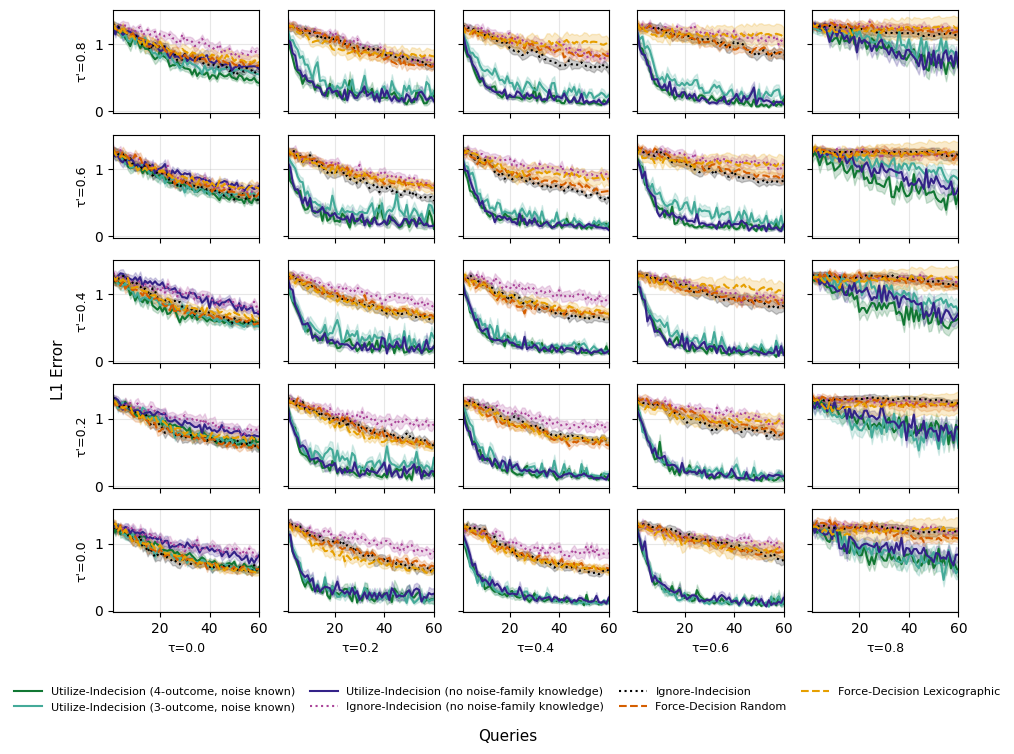

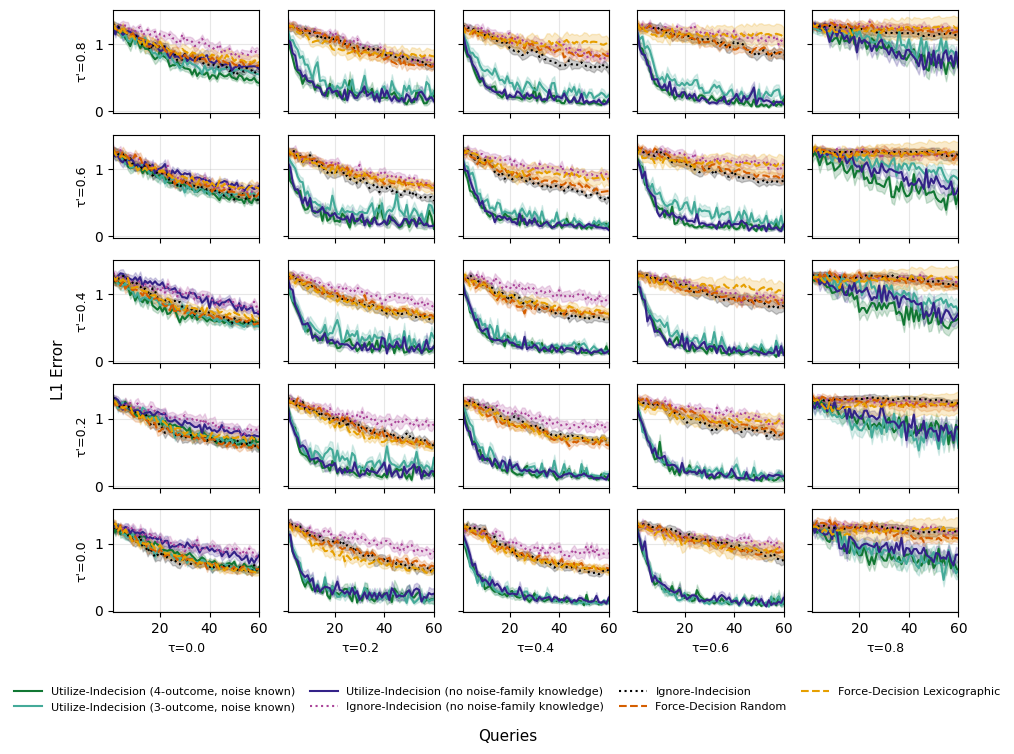

In [28]:
# ============================================================================
# Load the latest 8-method pkl and plot L1 + cosine similarity grids.
# ============================================================================

import glob, pickle

exec(open("plot_methods_grid.py").read())

_candidates = sorted(
    glob.glob("grid_sweep_11methods_*.pkl")
    # + glob.glob("grid_sweep_6methods_*.pkl")
    # + glob.glob("grid_sweep_8methods_*.pkl")
)
assert _candidates, "no grid_sweep_*methods_*.pkl found in this directory"
PKL_PATH = _candidates[-1]
print(f"loading {PKL_PATH}")

with open(PKL_PATH, "rb") as f:
    payload = pickle.load(f)
results = payload["results"]
md = payload["metadata"]

methods_to_plot = [                                    
      "multiframe",                  # Utilize-Indecision (4-outcome, noise known)
      "multiframe_3outcome",         # Utilize-Indecision (3-outcome, noise known)                   
      "multiframe_unknown_family",   # Utilize-Indecision (no noise-family knowledge)                
      "bt_mog",                      # BT (no noise-family knowledge) — MCMC + MoG                   
      "bt_hitandrun",                # Ignore-Indecision (MCMC, scale matched)                       
      "bt_hitandrun_random",         # Force-Decision Random (MCMC)                                  
      "bt_hitandrun_lex",            # Force-Decision Lex (MCMC)                                     
]
taus = md["taus"]
tau_primes = md["tau_primes"]
T = md["T"]

print(f"{len(methods_to_plot)} methods on {len(taus)}x{len(tau_primes)} grid (T={T})")
print()
print("--- L1 Error ---")
plot_methods_grid(
    results, taus, tau_primes, T,
    methods_to_plot=methods_to_plot,
    metric="l1",
    title=None,
    save_path=PKL_PATH.replace(".pkl", "_l1.pdf"),
    show_stderr=True,
)

# print()
# print("--- Cosine Similarity ---")
# plot_methods_grid(
#     results, taus, tau_primes, T,
#     methods_to_plot=methods_to_plot,
#     metric="cos_sims",
#     title=f"Cosine Similarity  (8 methods, gennorm noise, oracle beta={md.get('shape_beta')})",
#     save_path=PKL_PATH.replace(".pkl", "_cos.pdf"),
#     show_stderr=True,
# )
